# Support-Ticket Intelligence System
### End-to-end ML/DL workflow with ONNX Runtime, TensorRT and vLLM optimization (Colab T4)

A two-model customer-support pipeline:

1. **Classifier** – reads a ticket and predicts its *intent* (27 classes). Category (11 classes) and an *urgent* flag are derived from the intent.
2. **Reply drafter** – a small LLM (Qwen2.5-1.5B-Instruct + LoRA) writes a reply conditioned on the classifier output.

| Stage | Baseline | Main model | Optimization |
|---|---|---|---|
| Classification | TF-IDF + engineered features → Logistic Regression / LightGBM | Fine-tuned DistilBERT | ONNX → ONNX Runtime (FP32/FP16/INT8) → TensorRT (FP16/INT8) |
| Reply generation | BM25 retrieval of a past reply, and zero-shot LLM | LoRA fine-tuned Qwen2.5-1.5B | vLLM (continuous batching, PagedAttention, prefix caching), AWQ / 4-bit quantization vs. HF `generate()` |

**Notebook outline**

0. Setup  
1. Data collection and versioning  
2. Preprocessing and feature engineering  
3. Baselines (classifier)  
4. Fine-tuning DistilBERT  
5. Evaluation and validation (macro-F1, calibration, PR curves, bootstrap CIs, slices, distribution shift, error analysis)  
6. Classifier optimization: ONNX, ONNX Runtime, TensorRT + benchmark  
7. Reply generation: baselines, LoRA fine-tuning, quality evaluation  
8. LLM serving optimization: HF vs vLLM, FP16 vs AWQ vs 4-bit, prefix caching  
9. Pareto plots (speed vs. quality)  
10. Deployment: FastAPI + vLLM server, Locust load test, Dockerfile  
11. Summary

**Runtime:** `Runtime → Change runtime type → T4 GPU`. Expect roughly 2–3 hours end-to-end (the LoRA run, TensorRT INT8 build and the vLLM/AWQ environments dominate). Every expensive step has a switch in the config cell.

**Honest caveats, stated up front**

* The Bitext dataset is synthetic and template-like, so clean-test accuracy will be near-saturated for *every* model. To make the comparison informative this notebook adds (a) a synthetic **noisy / distribution-shift test set** and (b) **slices by Bitext linguistic flags** (colloquial, typos, etc.).
* Bitext has **no urgency label and no timestamps**. Urgency is a documented *proxy* (a fixed set of intents), and the "time-based split" is replaced by the distribution-shift test. Swap in your own data for real urgency/time signals.
* INT8 on ONNX Runtime is benchmarked on **CPU** (CUDA EP has no INT8 MatMul kernels for these ops); INT8 on GPU is covered by **TensorRT**.

## 0. Setup
### 0.1 Configuration
All knobs live here. Reduce `N_LLM_TRAIN` or switch off `RUN_AWQ` / `RUN_TRT_INT8` for a faster pass.

In [3]:
import os, sys, json, time, gc, re, random, hashlib, subprocess, warnings
from pathlib import Path
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")

WORK = Path("/content/work"); ART = WORK / "artifacts"; DATA = WORK / "data"
ONNX_DIR = ART / "onnx"; TRT_DIR = ART / "trt"; SERVE = WORK / "serve"
for d in (WORK, ART, DATA, ONNX_DIR, TRT_DIR, SERVE):
    d.mkdir(parents=True, exist_ok=True)

SEED = 42
MAX_LEN = 64                      # classifier sequence length (tickets are short)
CLS_MODEL = "distilbert-base-uncased"
LLM_BASE = "Qwen/Qwen2.5-1.5B-Instruct"

# ---- LLM settings ----
N_LLM_TRAIN = 3000                # LoRA training examples (raise for better quality)
LLM_EPOCHS = 1
N_LLM_EVAL = 96                   # test tickets used for generation quality + serving benchmarks
MAX_NEW_TOKENS = 200
MAX_SEQ = 512                     # max tokens (prompt + reply) in LoRA training

# ---- switches ----
RUN_TRT = True                    # build TensorRT engines
RUN_TRT_INT8 = True               # INT8 calibration build (slowest TRT step)
RUN_VLLM = True                   # create vLLM venv + benchmark
RUN_AWQ = True                    # create AutoAWQ venv + quantize the fine-tuned LLM
RUN_DEPLOY_DEMO = True            # start vLLM server + FastAPI + Locust
SAVE_TO_DRIVE = False             # copy artifacts to Google Drive at the end
print("work dir:", WORK)

work dir: /content/work


### 0.2 Install dependencies
`vLLM` pins its own PyTorch build, so installing it into the Colab environment would break TensorRT / ONNX Runtime / PEFT. We therefore install vLLM (and AutoAWQ) into **isolated virtual environments** later (Section 8) and call them as subprocesses. Here we only install the main environment.

`tensorrt-cu12` targets Colab's CUDA 12.x. If your Colab image ships a different CUDA major version, install the matching `tensorrt-cuXX` package.

In [2]:
%%bash
set -e
pip -q uninstall -y onnxruntime onnxruntime-gpu 2>/dev/null || true
pip -q install datasets scikit-learn lightgbm vaderSentiment rank_bm25 rouge_score bert_score peft accelerate \
    onnx onnxruntime-gpu onnxconverter-common mlflow tensorrt-cu12 fastapi uvicorn httpx locust nvidia-ml-py \
    anthropic seaborn uv
echo "install done"

install done


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [4]:
import torch, torch.nn as nn, torch.nn.functional as F
import onnx, onnxruntime as ort
import matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display

print("torch", torch.__version__, "| cuda", torch.version.cuda, "| gpu:", torch.cuda.get_device_name(0))
print("onnxruntime", ort.__version__, "| providers:", ort.get_available_providers())
try:
    import tensorrt as trt; print("tensorrt", trt.__version__)
except Exception as e:
    trt = None; print("TensorRT import failed:", e)

def seed_everything(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
seed_everything()

def gpu_used_mb():
    out = subprocess.run(["nvidia-smi", "--query-gpu=memory.used", "--format=csv,noheader,nounits"],
                         capture_output=True, text=True).stdout.strip().splitlines()[0]
    return int(out)

def free_gpu():
    gc.collect(); torch.cuda.empty_cache(); gc.collect()

def pctl(lat):
    lat = np.asarray(lat); return dict(p50=np.percentile(lat, 50), p95=np.percentile(lat, 95), p99=np.percentile(lat, 99))

# ---- experiment tracking (MLflow, local file store) ----
try:
    import mlflow
    mlflow.set_tracking_uri(f"file:{WORK}/mlruns"); mlflow.set_experiment("ticket-intelligence"); HAS_MLFLOW = True
except Exception as e:
    HAS_MLFLOW = False; print("MLflow disabled:", e)

def log_run(name, params=None, metrics=None):
    if not HAS_MLFLOW: return
    clean = lambda k: re.sub(r"[^\w\-\. /]", "_", str(k))
    with mlflow.start_run(run_name=name):
        mlflow.log_params({clean(k): v for k, v in (params or {}).items()})
        mlflow.log_metrics({clean(k): float(v) for k, v in (metrics or {}).items() if v is not None and np.isfinite(float(v))})

torch 2.11.0+cu130 | cuda 13.0 | gpu: Tesla T4
onnxruntime 1.30.0 | providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
tensorrt 11.3.0.99
MLflow disabled: The filesystem tracking backend (e.g., './mlruns') is in maintenance mode and will not receive further updates. Please migrate to a database backend (e.g., 'sqlite:///mlflow.db') to access the latest MLflow features. The `mlflow migrate-filestore` tool migrates your existing data losslessly. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance. If the filesystem backend is required for your workflow, set `MLFLOW_ALLOW_FILE_STORE=true` to opt out of this exception.


## 1. Data collection and versioning

**Primary source:** the public [Bitext customer-support dataset](https://huggingface.co/datasets/bitext/Bitext-customer-support-llm-chatbot-training-dataset) (~27k instruction/response pairs, 11 categories, 27 intents, plus `flags` describing linguistic variation: colloquial, typos, politeness, etc.).

It provides both what we need: ticket text with an intent label (classifier) and a reference agent response (generator).

*Extensions you can add with the same code path:* Banking77 / other HF support-ticket sets, or scraped StackExchange / Reddit support threads (clean with the same functions in Section 2).

In [5]:
from datasets import load_dataset
raw = load_dataset("bitext/Bitext-customer-support-llm-chatbot-training-dataset", split="train")
df_raw = raw.to_pandas()
print(df_raw.shape); print(df_raw.columns.tolist())
display(df_raw.head(3))
print("categories:", df_raw.category.nunique(), "| intents:", df_raw.intent.nunique())

README.md:   0%|          | 0.00/11.9k [00:00<?, ?B/s]

Bitext_Sample_Customer_Support_Training_(…): reconstructing file:   0%|          |  0.00B / 19.2MB            

Bitext_Sample_Customer_Support_Training_(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/26872 [00:00<?, ? examples/s]

(26872, 5)
['flags', 'instruction', 'category', 'intent', 'response']


,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...


categories: 11 | intents: 27


## 2. Preprocessing and feature engineering

### 2.1 Cleaning utilities (shared with the serving code)
We write the cleaning + prompt-building code to a module (`ticket_utils.py`) so the **notebook and the FastAPI service use identical logic** (no train/serve skew). It handles Unicode normalization, encoding errors, PII (emails, phones, URLs), signatures and placeholder normalization (`{{Order Number}}` → `[Order Number]`).

In [6]:
%%writefile /content/work/ticket_utils.py
import re, unicodedata

EMAIL_RE = re.compile(r"[\w\.-]+@[\w\.-]+\.\w+")
URL_RE = re.compile(r"https?://\S+|www\.\S+")
PHONE_RE = re.compile(r"(?<!\w)(?:\+?\d[\d\-\s().]{7,}\d)(?!\w)")
PLACEHOLDER_RE = re.compile(r"\{\{\s*([^}]+?)\s*\}\}")
SIG_RE = re.compile(r"(?is)\b(best regards|kind regards|sincerely|sent from my \w+)\b.*$")


def clean_text(s: str) -> str:
    s = unicodedata.normalize("NFKC", str(s))
    s = s.encode("utf-8", "ignore").decode("utf-8", "ignore")
    s = EMAIL_RE.sub(" <EMAIL> ", s)
    s = URL_RE.sub(" <URL> ", s)
    s = PHONE_RE.sub(" <PHONE> ", s)
    s = PLACEHOLDER_RE.sub(lambda m: "[" + m.group(1) + "]", s)
    s = SIG_RE.sub("", s)
    return re.sub(r"\s+", " ", s).strip()


def ascii_ratio(s: str) -> float:
    return sum(ord(c) < 128 for c in s) / max(len(s), 1)


SYSTEM_PROMPT = (
    "You are a customer-support agent for an online retail company. "
    "Write a reply to the customer's ticket.\n"
    "Guidelines:\n"
    "- Be polite, concise and empathetic; address the customer's exact request.\n"
    "- Give clear, numbered steps when an action is needed.\n"
    "- Keep placeholders such as {{Order Number}} or {{Customer Support Phone Number}} exactly as written; never invent order details, prices or dates.\n"
    "- If the issue needs a human, explain how to reach customer support.\n"
    "- End by offering further help."
)


def build_messages(ticket: str, intent: str = None, category: str = None):
    ctx = ""
    if intent:
        ctx = "Predicted category: %s\nPredicted intent: %s\n" % (category, intent)
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": ctx + "Customer ticket: " + ticket + "\n\nWrite the reply."},
    ]

Writing /content/work/ticket_utils.py


In [7]:
sys.path.insert(0, str(WORK))
from ticket_utils import clean_text, ascii_ratio, SYSTEM_PROMPT, build_messages

df = df_raw.copy()
n0 = len(df)
df["text"] = df["instruction"].map(clean_text)
df["response"] = df["response"].astype(str)

# language / encoding sanity: drop rows that are mostly non-ASCII (non-English or mojibake)
df = df[df.text.map(ascii_ratio) > 0.7]
df = df[df.text.str.len() >= 3]

# deduplicate on normalized text; report label conflicts first
norm = df.text.str.lower().str.replace(r"[^a-z0-9 ]", "", regex=True)
conflicts = df.groupby(norm).intent.nunique().gt(1).sum()
df = df.loc[~norm.duplicated()].reset_index(drop=True)
print(f"rows: {n0} -> {len(df)} after cleaning/dedupe | texts with conflicting labels: {conflicts}")

# ---- labels ----
intents = sorted(df.intent.unique()); label2id = {l: i for i, l in enumerate(intents)}; id2label = {i: l for l, i in label2id.items()}
categories = sorted(df.category.unique()); cat2id = {c: i for i, c in enumerate(categories)}
INTENT2CAT = df.drop_duplicates("intent").set_index("intent").category.to_dict()
df["y"] = df.intent.map(label2id)
df["cat_y"] = df.category.map(cat2id)
NUM_LABELS = len(intents)

# Urgency is a documented PROXY (Bitext has no urgency column): money / access / escalation intents.
URGENT_INTENTS = {"payment_issue", "complaint", "get_refund", "track_refund", "cancel_order",
                  "contact_human_agent", "recover_password", "registration_problems"}
URGENT_IDS = sorted(label2id[i] for i in URGENT_INTENTS if i in label2id)
df["urgent"] = df.y.isin(URGENT_IDS).astype(int)
print("intents:", NUM_LABELS, "| categories:", len(categories), "| urgent share: %.1f%%" % (100 * df.urgent.mean()))

rows: 26872 -> 24011 after cleaning/dedupe | texts with conflicting labels: 0
intents: 27 | categories: 11 | urgent share: 28.8%


### 2.2 Exploratory checks and stratified splits
80 / 10 / 10 split, stratified on intent. The **test set is touched only for final reporting** (model selection uses validation data). Splits are saved as Parquet with SHA-256 hashes (a lightweight stand-in for DVC; `dvc add data/` works the same way).

19208 2401 2402


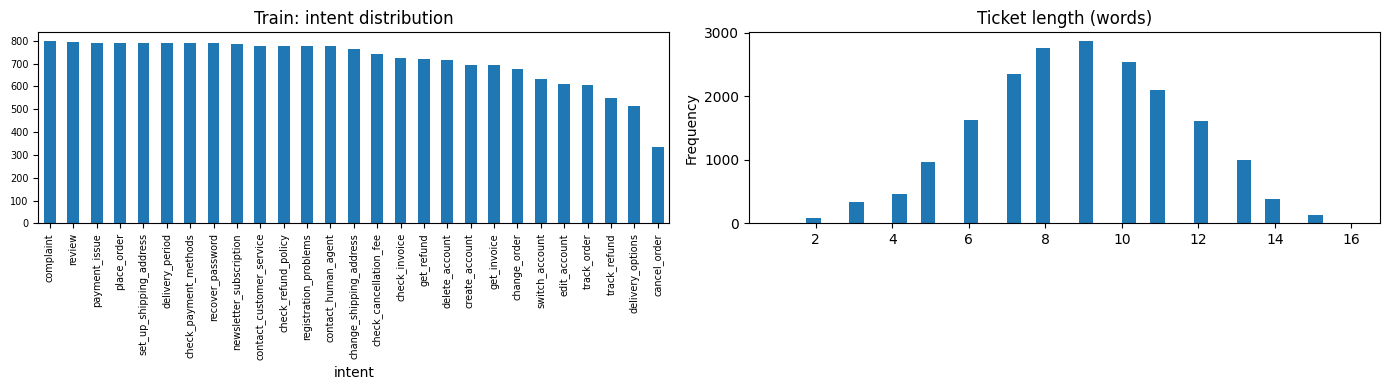

{
  "train": {
    "rows": 19208,
    "sha256": "7d794ce4bf5a0bb995a5bda2a98433ab48e4b5f05c96df4cd7172bbf1ba56d28"
  },
  "val": {
    "rows": 2401,
    "sha256": "65cb538c68889512203281c42e0d42a24c30207c629c1bc8ea042670a2894597"
  },
  "test": {
    "rows": 2402,
    "sha256": "a579d8a98054c947a5d09fa50658192dbadbc777a1039938b497528f5cc1dcf1"
  }
}


2534

In [8]:
from sklearn.model_selection import train_test_split
train_df, tmp = train_test_split(df, test_size=0.2, stratify=df.y, random_state=SEED)
val_df, test_df = train_test_split(tmp, test_size=0.5, stratify=tmp.y, random_state=SEED)
train_df, val_df, test_df = [d.reset_index(drop=True) for d in (train_df, val_df, test_df)]
print(len(train_df), len(val_df), len(test_df))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
train_df.intent.value_counts().plot.bar(ax=ax[0], title="Train: intent distribution"); ax[0].tick_params(labelsize=7)
train_df.text.str.split().str.len().plot.hist(bins=40, ax=ax[1], title="Ticket length (words)")
plt.tight_layout(); plt.show()

# ---- data versioning: parquet + hashes manifest ----
manifest = {}
for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    p = DATA / f"{name}.parquet"; d.to_parquet(p)
    manifest[name] = {"rows": len(d), "sha256": hashlib.sha256(p.read_bytes()).hexdigest()}
(DATA / "manifest.json").write_text(json.dumps(manifest, indent=2)); print(json.dumps(manifest, indent=2))

# ---- shared config for serving ----
CONFIG = dict(intents=intents, categories=categories, intent2cat=INTENT2CAT, urgent_intents=sorted(URGENT_INTENTS),
              max_len=MAX_LEN, system_prompt=SYSTEM_PROMPT)
(ART / "config.json").write_text(json.dumps(CONFIG, indent=2))

### 2.3 Feature engineering (for the classical baseline)
Engineered features: length, word count, caps ratio, punctuation ratio, `!`/`?` counts, digit ratio, placeholder flag, VADER sentiment, and keyword flags. (A "time of day" feature is omitted because Bitext has no timestamps; add it if your tickets do.)

Class imbalance is handled with balanced class weights (baselines) and weighted cross-entropy / optional focal loss (DistilBERT).

In [9]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
vader = SentimentIntensityAnalyzer()
KEYWORDS = {
    "kw_refund": r"refund|money back|reimburse", "kw_cancel": r"cancel", "kw_urgent": r"urgent|asap|immediately|right now|emergency",
    "kw_problem": r"not working|error|problem|issue|wrong|broken|can't|cannot|unable|failed",
    "kw_account": r"account|password|log ?in|sign ?in|regist", "kw_track": r"track|where is|status",
    "kw_invoice": r"invoice|bill|receipt", "kw_human": r"human|agent|representative|real person",
}
KW_RE = {k: re.compile(v, re.I) for k, v in KEYWORDS.items()}

def featurize(texts):
    rows = []
    for t in texts:
        n = max(len(t), 1)
        r = dict(n_chars=len(t), n_words=len(t.split()), caps_ratio=sum(c.isupper() for c in t) / n,
                 punct_ratio=sum((not c.isalnum()) and (not c.isspace()) for c in t) / n,
                 n_excl=t.count("!"), n_q=t.count("?"), digit_ratio=sum(c.isdigit() for c in t) / n,
                 has_placeholder=int("[" in t), sentiment=vader.polarity_scores(t)["compound"])
        r.update({k: int(bool(rx.search(t))) for k, rx in KW_RE.items()})
        rows.append(r)
    return pd.DataFrame(rows)

F_train, F_val, F_test = featurize(train_df.text), featurize(val_df.text), featurize(test_df.text)
FEAT_COLS = F_train.columns.tolist()
display(F_train.describe().T[["mean", "std", "min", "max"]].round(3))

,mean,std,min,max
n_chars,46.681,10.650,6.000,88.000
n_words,8.857,2.561,1.000,16.000
caps_ratio,0.019,0.022,0.000,0.192
punct_ratio,0.015,0.020,0.000,0.103
n_excl,0.000,0.000,0.000,0.000
n_q,0.196,0.397,0.000,1.000
digit_ratio,0.006,0.032,0.000,0.556
has_placeholder,0.173,0.378,0.000,1.000
sentiment,0.068,0.251,-0.776,0.784
kw_refund,0.072,0.258,0.000,1.000


## 3. Baselines (classifier)
### 3.1 Shared evaluation utilities
Metrics: accuracy, **macro-F1**, **ECE** (expected calibration error), and **average precision for the urgent flag** (score = summed probability of urgent intents).

In [10]:
from sklearn.metrics import (accuracy_score, f1_score, classification_report, confusion_matrix,
                             average_precision_score, precision_recall_curve)

def ece_score(proba, y, n_bins=15):
    conf, pred = proba.max(1), proba.argmax(1); correct = (pred == y); edges = np.linspace(0, 1, n_bins + 1); ece = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.any(): ece += m.mean() * abs(correct[m].mean() - conf[m].mean())
    return ece

def urgent_scores(proba): return proba[:, URGENT_IDS].sum(1)

def evaluate(y, proba, name, split):
    pred = proba.argmax(1)
    return dict(model=name, split=split, acc=accuracy_score(y, pred), macro_f1=f1_score(y, pred, average="macro"),
                ece=ece_score(proba, y), urgent_AP=average_precision_score(np.isin(y, URGENT_IDS), urgent_scores(proba)))

def softmax(x): e = np.exp(x - x.max(1, keepdims=True)); return e / e.sum(1, keepdims=True)

y_train, y_val, y_test = train_df.y.values, val_df.y.values, test_df.y.values
EVAL_ROWS, PROBA = [], {}      # PROBA[model][split] -> class probabilities

# ---- distribution-shift test set: typos, case and punctuation noise (simulated drift) ----
def add_noise(t, rng):
    out = []
    for w in t.split():
        if len(w) > 3 and rng.random() < 0.15:
            i = int(rng.integers(1, len(w) - 1)); op = int(rng.integers(0, 3))
            if op == 0: w = w[:i] + w[i + 1:]                       # drop a char
            elif op == 1: w = w[:i] + w[i] + w[i:]                  # duplicate a char
            else: w = w[:i - 1] + w[i] + w[i - 1] + w[i + 1:]       # swap neighbours
        out.append(w)
    s = " ".join(out)
    if rng.random() < 0.3: s = s.lower()
    if rng.random() < 0.3: s = re.sub(r"[?.!,]", "", s)
    return s

rng = np.random.default_rng(SEED)
noisy_df = test_df.copy(); noisy_df["text"] = [add_noise(t, rng) for t in test_df.text]
F_noisy = featurize(noisy_df.text)
display(pd.DataFrame({"clean": test_df.text[:4], "noisy": noisy_df.text[:4]}))

,clean,noisy
0,where do I see what methods for delivery are a...,where do I see what methods for delivery are a...
1,help me submit some feedback about a product,hellp me submit some feedback about a product
2,need help to see how long it takes for my ship...,need help to see how long it takes for my ship...
3,want help buying a product,want hep buying a product


### 3.2 Baseline A: TF-IDF (1–2-grams) + engineered features → Logistic Regression
Scaled engineered features are concatenated with TF-IDF features inside a single scikit-learn pipeline (so cross-validation refits the vectorizer inside every fold, avoiding leakage). `class_weight="balanced"` handles imbalance. We also report **5-fold stratified CV** on train+val.

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

def make_lr():
    pre = ColumnTransformer([("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True), "text"),
                             ("num", StandardScaler(), FEAT_COLS)])
    return Pipeline([("pre", pre), ("clf", LogisticRegression(C=10, max_iter=300, class_weight="balanced"))])

mk = lambda d, f: pd.concat([d[["text"]].reset_index(drop=True), f.reset_index(drop=True)], axis=1)
X_train, X_val, X_test, X_noisy = mk(train_df, F_train), mk(val_df, F_val), mk(test_df, F_test), mk(noisy_df, F_noisy)

t0 = time.time()
lr = make_lr().fit(X_train, y_train)
print(f"LR fit: {time.time() - t0:.0f}s | val macro-F1: {f1_score(y_val, lr.predict(X_val), average='macro'):.4f}")

# stratified 5-fold CV on train+val (never touches test)
X_tv, y_tv = pd.concat([X_train, X_val]), np.concatenate([y_train, y_val])
cv = cross_val_score(make_lr(), X_tv, y_tv, cv=StratifiedKFold(5, shuffle=True, random_state=SEED), scoring="f1_macro", n_jobs=-1)
print("5-fold CV macro-F1: %.4f +/- %.4f" % (cv.mean(), cv.std()))

PROBA["TFIDF+LR"] = {"clean": lr.predict_proba(X_test), "noisy": lr.predict_proba(X_noisy)}

LR fit: 31s | val macro-F1: 0.9939
5-fold CV macro-F1: 0.9931 +/- 0.0022


### 3.3 Baseline B: TF-IDF + engineered features → LightGBM
Gradient boosting on sparse TF-IDF (top 5k features) plus the dense engineered features, with early stopping on validation.

In [12]:
import scipy.sparse as sp, lightgbm as lgb
tf_gb = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=5000, sublinear_tf=True)
build = lambda txt, feats, fit=False: sp.hstack([tf_gb.fit_transform(txt) if fit else tf_gb.transform(txt),
                                                 sp.csr_matrix(feats.values.astype("float32"))]).tocsr().astype("float32")
G_train = build(train_df.text, F_train, fit=True); G_val = build(val_df.text, F_val)
G_test = build(test_df.text, F_test); G_noisy = build(noisy_df.text, F_noisy)

t0 = time.time()
gbm = lgb.LGBMClassifier(n_estimators=250, learning_rate=0.1, num_leaves=31, colsample_bytree=0.3, class_weight="balanced",
                         n_jobs=-1, verbose=-1, random_state=SEED)
gbm.fit(G_train, y_train, eval_set=[(G_val, y_val)], callbacks=[lgb.early_stopping(20, verbose=False)])
print(f"LightGBM fit: {time.time() - t0:.0f}s | best iter {gbm.best_iteration_} | val macro-F1: {f1_score(y_val, gbm.predict(G_val), average='macro'):.4f}")
PROBA["TFIDF+LightGBM"] = {"clean": gbm.predict_proba(G_test), "noisy": gbm.predict_proba(G_noisy)}
log_run("baseline_tfidf_lr", {"C": 10, "ngram": "1-2"}, {"cv_macro_f1": cv.mean(), "val_macro_f1": f1_score(y_val, lr.predict(X_val), average="macro")})

LightGBM fit: 101s | best iter 116 | val macro-F1: 0.9911


## 4. Main classifier: fine-tuned DistilBERT
Standard fine-tuning with mixed precision (FP16 autocast + GradScaler), AdamW, linear warm-up/decay. Loss is **class-weighted cross-entropy**; set `USE_FOCAL = True` for focal loss. The checkpoint with the best **validation** macro-F1 is kept.

In [13]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.utils.class_weight import compute_class_weight

tok = AutoTokenizer.from_pretrained(CLS_MODEL)
def encode(texts):
    e = tok(list(texts), padding="max_length", truncation=True, max_length=MAX_LEN, return_tensors="np")
    return e["input_ids"].astype(np.int64), e["attention_mask"].astype(np.int64)

ids_train, mask_train = encode(train_df.text); ids_val, mask_val = encode(val_df.text)
ids_test, mask_test = encode(test_df.text); ids_noisy, mask_noisy = encode(noisy_df.text)
print("token length p99 (train, untruncated):", int(np.percentile([len(tok(t).input_ids) for t in train_df.text[:3000]], 99)), "| MAX_LEN =", MAX_LEN)

cls_w = torch.tensor(compute_class_weight("balanced", classes=np.arange(NUM_LABELS), y=y_train), dtype=torch.float32, device="cuda")

class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0): super().__init__(); self.weight, self.gamma = weight, gamma
    def forward(self, logits, target):
        logp = F.log_softmax(logits, -1); logp_t = logp.gather(1, target[:, None]).squeeze(1); p_t = logp_t.exp()
        w = self.weight[target] if self.weight is not None else 1.0
        return (-w * (1 - p_t) ** self.gamma * logp_t).mean()

USE_FOCAL = False
criterion = FocalLoss(cls_w) if USE_FOCAL else nn.CrossEntropyLoss(weight=cls_w)

@torch.no_grad()
def predict_logits_torch(model, ids, mask, bs=128):
    model.eval(); out = []
    for i in range(0, len(ids), bs):
        with torch.autocast("cuda", dtype=torch.float16):
            out.append(model(input_ids=torch.from_numpy(ids[i:i + bs]).cuda(), attention_mask=torch.from_numpy(mask[i:i + bs]).cuda()).logits.float().cpu())
    return torch.cat(out).numpy()

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

token length p99 (train, untruncated): 21 | MAX_LEN = 64


In [14]:
EPOCHS, BS, LR_ = 3, 32, 5e-5
model = AutoModelForSequenceClassification.from_pretrained(CLS_MODEL, num_labels=NUM_LABELS, id2label=id2label, label2id=label2id).cuda()
opt = torch.optim.AdamW(model.parameters(), lr=LR_, weight_decay=0.01)
steps = EPOCHS * (len(ids_train) // BS); sched = get_linear_schedule_with_warmup(opt, int(0.06 * steps), steps)
scaler = torch.amp.GradScaler("cuda")
best_f1, best_state, history = -1, None, []

for ep in range(EPOCHS):
    model.train(); perm = np.random.permutation(len(ids_train)); t0 = time.time(); losses = []
    for i in range(0, len(perm) - BS + 1, BS):
        b = perm[i:i + BS]
        with torch.autocast("cuda", dtype=torch.float16):
            logits = model(input_ids=torch.from_numpy(ids_train[b]).cuda(), attention_mask=torch.from_numpy(mask_train[b]).cuda()).logits
        loss = criterion(logits.float(), torch.from_numpy(y_train[b]).cuda())
        opt.zero_grad(set_to_none=True); scaler.scale(loss).backward(); scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); scaler.step(opt); scaler.update(); sched.step(); losses.append(loss.item())
    vl = predict_logits_torch(model, ids_val, mask_val); vf1 = f1_score(y_val, vl.argmax(1), average="macro")
    history.append(dict(epoch=ep + 1, train_loss=np.mean(losses), val_macro_f1=vf1, sec=time.time() - t0)); print(history[-1])
    if vf1 > best_f1: best_f1, best_state = vf1, {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

model.load_state_dict(best_state)
CLS_DIR = ART / "distilbert_ticket"; model.save_pretrained(CLS_DIR); tok.save_pretrained(CLS_DIR)
PROBA["DistilBERT"] = {"clean": softmax(predict_logits_torch(model, ids_test, mask_test)),
                       "noisy": softmax(predict_logits_torch(model, ids_noisy, mask_noisy))}
val_logits_bert = predict_logits_torch(model, ids_val, mask_val)      # kept for temperature scaling
log_run("distilbert", {"epochs": EPOCHS, "lr": LR_, "bs": BS, "focal": USE_FOCAL}, {"val_macro_f1": best_f1})
del model, opt, scaler, best_state; free_gpu()          # free the GPU so later memory measurements are clean

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'epoch': 1, 'train_loss': np.float64(0.6360317539439226), 'val_macro_f1': 0.9938882208796508, 'sec': 44.091264963150024}
{'epoch': 2, 'train_loss': np.float64(0.008288915776065551), 'val_macro_f1': 0.9954131955664599, 'sec': 45.61170029640198}
{'epoch': 3, 'train_loss': np.float64(0.0026978742319624873), 'val_macro_f1': 0.9976228989511065, 'sec': 43.49472451210022}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## 5. Evaluation and validation
### 5.1 Headline comparison (clean test and noisy / shifted test)

In [15]:
EVAL_ROWS = [evaluate(y_test, PROBA[m][s], m, s) for m in PROBA for s in ("clean", "noisy")]
eval_df = pd.DataFrame(EVAL_ROWS).round(4); display(eval_df.pivot(index="model", columns="split", values=["acc", "macro_f1", "ece", "urgent_AP"]))
for r in EVAL_ROWS: log_run(f"eval_{r['model']}_{r['split']}", {"model": r["model"], "split": r["split"]}, {k: r[k] for k in ("acc", "macro_f1", "ece", "urgent_AP")})

acc         macro_f1             ece         urgent_AP  \
split            clean   noisy    clean   noisy   clean   noisy     clean   
model                                                                       
DistilBERT      0.9983  0.9842   0.9980  0.9836  0.0006  0.0095    0.9999   
TFIDF+LR        0.9946  0.9675   0.9944  0.9659  0.0218  0.0394    0.9998   
TFIDF+LightGBM  0.9883  0.9575   0.9878  0.9558  0.0088  0.0160    0.9998   

                        
split            noisy  
model                   
DistilBERT      0.9995  
TFIDF+LR        0.9965  
TFIDF+LightGBM  0.9980

### 5.2 Per-class precision / recall and confusion matrices
The category-level matrix (11×11) is readable; the intent-level view lists the most frequent confusions.

Worst 8 intents by F1 (DistilBERT, clean test):


,precision,recall,f1-score,support
track_order,1.000,0.974,0.987,76.0
cancel_order,0.976,1.000,0.988,41.0
change_order,0.988,1.000,0.994,84.0
get_invoice,0.989,1.000,0.994,86.0
check_invoice,1.000,0.989,0.994,91.0
get_refund,0.989,1.000,0.995,91.0
check_refund_policy,1.000,0.990,0.995,97.0
check_cancellation_fee,1.000,1.000,1.000,93.0


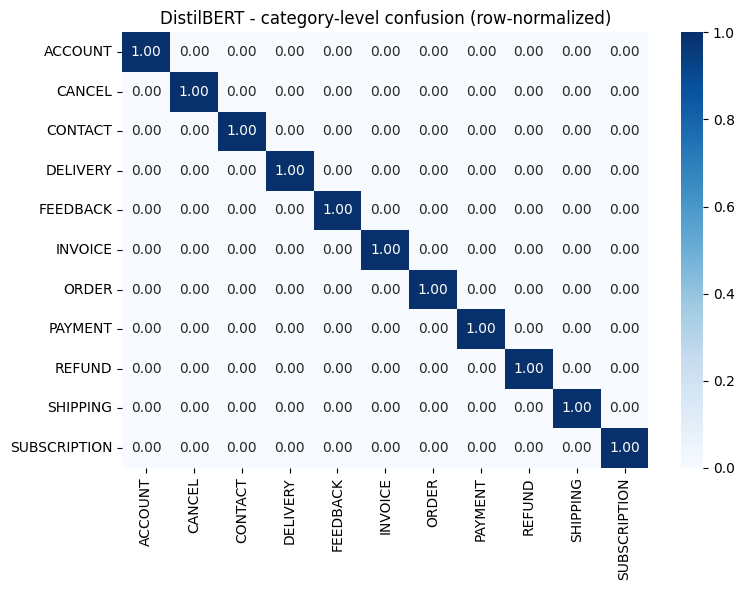

Category accuracy derived from intent prediction: 1.0000
Top intent confusions: [(('check_invoice', 'get_invoice'), 1), (('track_order', 'cancel_order'), 1), (('track_order', 'change_order'), 1), (('check_refund_policy', 'get_refund'), 1)]


In [16]:
from collections import Counter
pred_bert = PROBA["DistilBERT"]["clean"].argmax(1)
rep = pd.DataFrame(classification_report(y_test, pred_bert, target_names=intents, output_dict=True, zero_division=0)).T
print("Worst 8 intents by F1 (DistilBERT, clean test):"); display(rep.iloc[:NUM_LABELS].sort_values("f1-score").head(8).round(3))

cat_true = test_df.cat_y.values; cat_pred = np.array([cat2id[INTENT2CAT[id2label[i]]] for i in pred_bert])
cm = confusion_matrix(cat_true, cat_pred, normalize="true")
plt.figure(figsize=(8, 6)); sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=categories, yticklabels=categories)
plt.title("DistilBERT - category-level confusion (row-normalized)"); plt.tight_layout(); plt.show()
print("Category accuracy derived from intent prediction: %.4f" % (cat_true == cat_pred).mean())
print("Top intent confusions:", Counter((id2label[a], id2label[b]) for a, b in zip(y_test, pred_bert) if a != b).most_common(6))

### 5.3 Calibration (ECE, reliability diagram, temperature scaling) and PR curves for urgent tickets
A transformer can be accurate but over-confident. We fit a single **temperature** on the validation logits and re-measure ECE on test. The PR curve treats `urgent` as a binary detection problem.

temperature = 1.010 | ECE before 0.0006 -> after 0.0007


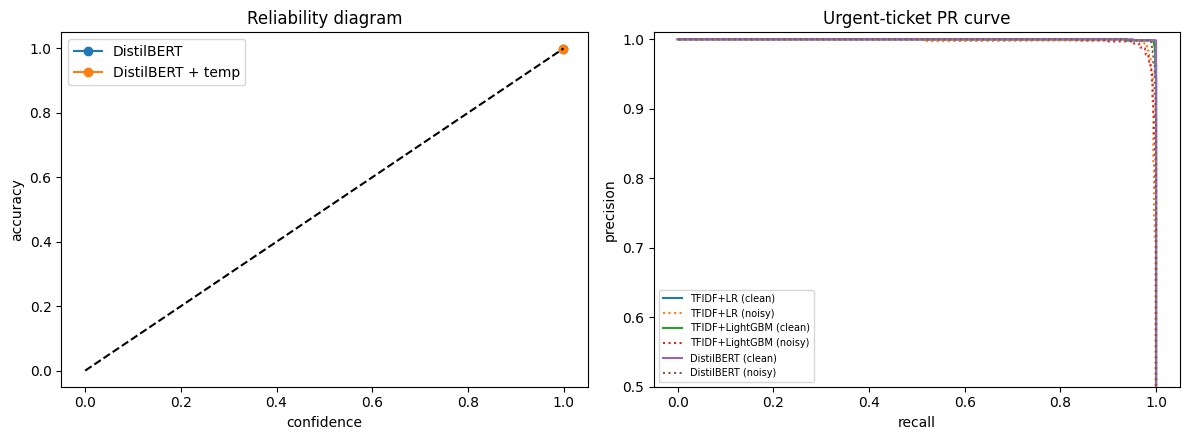

In [17]:
def fit_temperature(logits, y):
    T = torch.nn.Parameter(torch.ones(1)); lg, yy = torch.tensor(logits), torch.tensor(y); o = torch.optim.LBFGS([T], lr=0.1, max_iter=200)
    def closure(): o.zero_grad(); l = F.cross_entropy(lg / T, yy); l.backward(); return l
    o.step(closure); return T.item()

T_opt = fit_temperature(val_logits_bert, y_val)
lg_test = np.log(PROBA["DistilBERT"]["clean"] + 1e-12)   # log-probs differ from logits by a per-row constant -> same softmax
p_cal = softmax(lg_test / T_opt)
print(f"temperature = {T_opt:.3f} | ECE before {ece_score(PROBA['DistilBERT']['clean'], y_test):.4f} -> after {ece_score(p_cal, y_test):.4f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for name, p in [("DistilBERT", PROBA["DistilBERT"]["clean"]), ("DistilBERT + temp", p_cal)]:
    conf, corr = p.max(1), (p.argmax(1) == y_test); bins = np.linspace(0, 1, 11); xs, ys = [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.sum() > 5: xs.append(conf[m].mean()); ys.append(corr[m].mean())
    ax[0].plot(xs, ys, "o-", label=name)
ax[0].plot([0, 1], [0, 1], "k--"); ax[0].set(title="Reliability diagram", xlabel="confidence", ylabel="accuracy"); ax[0].legend()

for m in PROBA:
    for s, ls in (("clean", "-"), ("noisy", ":")):
        pr, rc, _ = precision_recall_curve(np.isin(y_test, URGENT_IDS), urgent_scores(PROBA[m][s])); ax[1].plot(rc, pr, ls, label=f"{m} ({s})")
ax[1].set(title="Urgent-ticket PR curve", xlabel="recall", ylabel="precision", ylim=(0.5, 1.01)); ax[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

### 5.4 Is the transformer really better? Paired bootstrap confidence intervals
Resample the test set with replacement 1,000 times and compute the macro-F1 difference (DistilBERT − baseline) on each resample. If the 95% CI excludes 0, the difference is statistically meaningful.

In [18]:
def paired_bootstrap(y, pa, pb, n=1000, seed=SEED):
    rng = np.random.default_rng(seed); diffs = []
    for _ in range(n):
        idx = rng.integers(0, len(y), len(y))
        diffs.append(f1_score(y[idx], pb[idx], average="macro") - f1_score(y[idx], pa[idx], average="macro"))
    d = np.array(diffs); return d.mean(), np.percentile(d, 2.5), np.percentile(d, 97.5), (d <= 0).mean()

rows = []
for base in ("TFIDF+LR", "TFIDF+LightGBM"):
    for s in ("clean", "noisy"):
        m, lo, hi, p = paired_bootstrap(y_test, PROBA[base][s].argmax(1), PROBA["DistilBERT"][s].argmax(1))
        rows.append(dict(baseline=base, split=s, delta_macro_f1=m, ci95_low=lo, ci95_high=hi, p_value_boot=p, significant=lo > 0))
display(pd.DataFrame(rows).round(4))

,baseline,split,delta_macro_f1,ci95_low,ci95_high,p_value_boot,significant
0,TFIDF+LR,clean,0.0037,0.0012,0.0067,0.0,True
1,TFIDF+LR,noisy,0.0176,0.0105,0.0251,0.0,True
2,TFIDF+LightGBM,clean,0.0103,0.0061,0.0151,0.0,True
3,TFIDF+LightGBM,noisy,0.0277,0.0187,0.0360,0.0,True


### 5.5 Slice analysis (Bitext linguistic flags) and error analysis
Bitext's `flags` column marks linguistic variation in each ticket (see the dataset card for letter meanings). Slicing by flag shows *where* each model fails, which matters more than a single average.

In [20]:
# 5.5 Slice analysis (Bitext linguistic flags) and error analysis

flags = test_df["flags"].fillna("").astype(str)

letters = sorted(set("".join(flags)))

rows = []

for L in letters:
    m = flags.str.contains(L, regex=False).values

    if m.sum() < 30:
        continue

    rows.append(
        dict(
            flag=L,
            n=int(m.sum()),
            **{
                k: accuracy_score(
                    y_test[m],
                    PROBA[k]["clean"].argmax(1)[m]
                )
                for k in PROBA
            }
        )
    )

slice_df = pd.DataFrame(rows).round(4)

display(slice_df.sort_values("DistilBERT"))


# Error analysis on noisy test set
wrong = np.where(
    PROBA["DistilBERT"]["noisy"].argmax(1) != y_test
)[0]

print(
    f"\nDistilBERT errors on noisy test: "
    f"{len(wrong)} / {len(y_test)}"
)

display(
    pd.DataFrame({
        "noisy_text": noisy_df["text"].values[wrong][:8],
        "true": [
            id2label[i]
            for i in y_test[wrong][:8]
        ],
        "pred": [
            id2label[i]
            for i in PROBA["DistilBERT"]["noisy"].argmax(1)[wrong[:8]]
        ]
    })
)

,flag,n,TFIDF+LR,TFIDF+LightGBM,DistilBERT
10,W,123,0.9919,0.9756,0.9919
11,Z,496,0.9778,0.9577,0.9940
3,I,723,0.9959,0.9903,0.9972
9,Q,851,0.9965,0.9859,0.9976
5,L,2201,0.9950,0.9882,0.9982
0,B,2402,0.9946,0.9883,0.9983
2,E,173,0.9942,0.9942,1.0000
1,C,269,1.0000,0.9926,1.0000
7,N,47,1.0000,1.0000,1.0000
6,M,480,0.9958,0.9896,1.0000



DistilBERT errors on noisy test: 38 / 2402


,noisy_text,true,pred
0,i don't know what to do to reomve a [account c...,delete_account,create_account
1,pudtae standard account,edit_account,create_account
2,want asistance acncelling a [ccount Type] account,delete_account,create_account
3,what do I need to do to see your pyament methods,check_payment_methods,delivery_options
4,could you help me check what hsipment options ...,delivery_options,check_payment_methods
5,i ned assistance to make a copmlaint,complaint,place_order
6,can I ordrr from [Deliivery City],delivery_options,check_invoice
7,can you give me inforamtion about the damn shi...,delivery_options,delivery_period


### 5.6 Drift check on engineered features (PSI and KS test)
Population Stability Index (PSI) compares the training feature distribution against the shifted set; rule of thumb: PSI > 0.2 means significant drift. In production, run the same check on a rolling window of live tickets (or use Evidently's `DataDriftPreset` for an HTML report).

In [21]:
from scipy.stats import ks_2samp
def psi(a, b, bins=10):
    edges = np.unique(np.quantile(a, np.linspace(0, 1, bins + 1)))
    if len(edges) < 3: return 0.0
    edges[0], edges[-1] = -np.inf, np.inf
    pa = np.histogram(a, edges)[0] / len(a) + 1e-6; pb = np.histogram(b, edges)[0] / len(b) + 1e-6
    return float(((pb - pa) * np.log(pb / pa)).sum())

drift = pd.DataFrame([dict(feature=c, PSI=psi(F_train[c].values, F_noisy[c].values), KS_p=ks_2samp(F_train[c], F_noisy[c]).pvalue) for c in FEAT_COLS])
display(drift.sort_values("PSI", ascending=False).head(8).round(4))

,feature,PSI,KS_p
2,caps_ratio,0.0890,0.0000
3,punct_ratio,0.0106,0.0000
8,sentiment,0.0100,0.0452
0,n_chars,0.0015,0.9961
1,n_words,0.0008,1.0000
4,n_excl,0.0000,1.0000
5,n_q,0.0000,0.0000
6,digit_ratio,0.0000,1.0000


## 6. Classifier optimization: ONNX → ONNX Runtime → TensorRT

### 6.1 Export to ONNX
Dynamic batch and sequence axes, opset 17, eager attention (cleanest export). We check numerical parity against PyTorch.

In [22]:
onnx_fp32 = str(ONNX_DIR / "model_fp32.onnx")
m_exp = AutoModelForSequenceClassification.from_pretrained(CLS_DIR, attn_implementation="eager").eval()

class LogitsOnly(nn.Module):
    def __init__(self, m): super().__init__(); self.m = m
    def forward(self, input_ids, attention_mask): return self.m(input_ids=input_ids, attention_mask=attention_mask).logits

dummy = (torch.from_numpy(ids_test[:2]), torch.from_numpy(mask_test[:2]))
export_kwargs = dict(input_names=["input_ids", "attention_mask"], output_names=["logits"],
                     dynamic_axes={"input_ids": {0: "batch", 1: "seq"}, "attention_mask": {0: "batch", 1: "seq"}, "logits": {0: "batch"}},
                     opset_version=17, do_constant_folding=True)
try:
    torch.onnx.export(LogitsOnly(m_exp), dummy, onnx_fp32, dynamo=False, **export_kwargs)      # legacy TorchScript exporter
except TypeError:
    torch.onnx.export(LogitsOnly(m_exp), dummy, onnx_fp32, **export_kwargs)
onnx.checker.check_model(onnx.load(onnx_fp32)); print("exported:", onnx_fp32, f"({os.path.getsize(onnx_fp32) / 1e6:.0f} MB)")

# parity check vs PyTorch
sess_chk = ort.InferenceSession(onnx_fp32, providers=["CPUExecutionProvider"])
o = sess_chk.run(None, {"input_ids": ids_test[:64], "attention_mask": mask_test[:64]})[0]
with torch.no_grad(): t = m_exp(input_ids=torch.from_numpy(ids_test[:64]), attention_mask=torch.from_numpy(mask_test[:64])).logits.numpy()
print("max |ONNX - torch| logits:", float(np.abs(o - t).max()), "| top-1 agreement:", float((o.argmax(1) == t.argmax(1)).mean()))
del sess_chk, m_exp

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

exported: /content/work/artifacts/onnx/model_fp32.onnx (268 MB)
max |ONNX - torch| logits: 1.3785500526428223 | top-1 agreement: 1.0


### 6.2 ONNX Runtime optimizations
* **Graph optimizations** (`ORT_ENABLE_ALL`): constant folding, node fusion (LayerNorm, GELU, attention where matched).
* **FP16 on GPU**: ORT's transformer optimizer fuses attention/LayerNorm then converts weights to FP16 (falls back to a plain FP16 conversion if fusion does not match DistilBERT's graph).
* **INT8 on CPU**: *dynamic* quantization (weights INT8, activations quantized at runtime) and *static* QDQ quantization (activations calibrated on 256 training tickets).

In [23]:
from onnxruntime.quantization import quantize_dynamic, quantize_static, QuantType, QuantFormat, CalibrationDataReader

# ---- FP16 (GPU) ----
onnx_fp16 = str(ONNX_DIR / "model_fp16.onnx")
try:
    from onnxruntime.transformers import optimizer
    mo = optimizer.optimize_model(onnx_fp32, model_type="bert", num_heads=12, hidden_size=768, use_gpu=True)
    mo.convert_float_to_float16(keep_io_types=True); mo.save_model_to_file(onnx_fp16); print("FP16 via ORT transformer optimizer (fused graph)")
except Exception as e:
    print("transformer optimizer path failed -> plain FP16 conversion:", repr(e)[:150])
    from onnxconverter_common import float16
    onnx.save(float16.convert_float_to_float16(onnx.load(onnx_fp32), keep_io_types=True), onnx_fp16)

# ---- INT8 dynamic (CPU) ----
onnx_int8_dyn = str(ONNX_DIR / "model_int8_dynamic.onnx")
quantize_dynamic(onnx_fp32, onnx_int8_dyn, weight_type=QuantType.QInt8)

# ---- INT8 static QDQ (CPU), calibrated on 256 training tickets ----
class TicketCalib(CalibrationDataReader):
    def __init__(self, ids, mask, bs=32):
        self.b = [{"input_ids": ids[i:i + bs], "attention_mask": mask[i:i + bs]} for i in range(0, len(ids), bs)]; self.it = iter(self.b)
    def get_next(self): return next(self.it, None)
    def rewind(self): self.it = iter(self.b)

onnx_pre = str(ONNX_DIR / "model_fp32_pre.onnx")
try:
    from onnxruntime.quantization.shape_inference import quant_pre_process
    quant_pre_process(onnx_fp32, onnx_pre, skip_symbolic_shape=True)
except Exception as e:
    print("quant_pre_process skipped:", repr(e)[:100]); onnx_pre = onnx_fp32
onnx_int8_static = str(ONNX_DIR / "model_int8_static_qdq.onnx")
quantize_static(onnx_pre, onnx_int8_static, TicketCalib(ids_train[:256], mask_train[:256]), quant_format=QuantFormat.QDQ,
                activation_type=QuantType.QUInt8, weight_type=QuantType.QInt8, per_channel=True)
for p in (onnx_fp32, onnx_fp16, onnx_int8_dyn, onnx_int8_static): print(f"{Path(p).name:32s} {os.path.getsize(p) / 1e6:7.1f} MB")

FP16 via ORT transformer optimizer (fused graph)


model_fp32.onnx                    268.0 MB
model_fp16.onnx                    134.1 MB
model_int8_dynamic.onnx             67.4 MB
model_int8_static_qdq.onnx          67.6 MB


### 6.3 TensorRT engines (FP16 and INT8)
We use the native TensorRT Python API: parse the ONNX graph, add an optimization profile (batch 1…64, sequence fixed at 64) and build:

* **FP16** – `BuilderFlag.FP16`.
* **INT8** – entropy calibration (`IInt8EntropyCalibrator2`) over 512 training tickets, with FP16 fallback for layers that stay sensitive. If the installed TensorRT version rejects the implicit-calibration path, we fall back to **explicit quantization**: a QDQ ONNX with symmetric INT8 produced by ONNX Runtime.

Engines are specific to the GPU/TensorRT version they were built on. Build time on a T4: ~1–2 min (FP16), ~3–6 min (INT8).

In [26]:
if RUN_TRT and trt is not None:

    TRT2TORCH = {
        trt.DataType.FLOAT: torch.float32,
        trt.DataType.HALF: torch.float16,
        trt.DataType.INT32: torch.int32,
        trt.DataType.INT64: torch.int64,
        trt.DataType.INT8: torch.int8,
        trt.DataType.BOOL: torch.bool,
    }

    def build_trt_engine(
        onnx_path,
        engine_path,
        precision,
        max_bs=64,
        seq=MAX_LEN,
    ):
        logger = trt.Logger(trt.Logger.WARNING)
        builder = trt.Builder(logger)

        # Explicit batch/network
        try:
            network = builder.create_network(
                1 << int(trt.NetworkDefinitionCreationFlag.EXPLICIT_BATCH)
            )
        except Exception:
            network = builder.create_network()

        parser = trt.OnnxParser(network, logger)

        if not parser.parse(Path(onnx_path).read_bytes()):
            errors = "; ".join(
                str(parser.get_error(i))
                for i in range(parser.num_errors)
            )
            raise RuntimeError("ONNX parse failed: " + errors)

        cfg = builder.create_builder_config()

        # TensorRT 8/10 compatible workspace configuration
        try:
            cfg.set_memory_pool_limit(
                trt.MemoryPoolType.WORKSPACE,
                2 << 30
            )
        except Exception:
            cfg.max_workspace_size = 2 << 30

        # Optimization profile
        profile = builder.create_optimization_profile()

        for i in range(network.num_inputs):
            name = network.get_input(i).name
            profile.set_shape(
                name,
                (1, seq),
                (8, seq),
                (max_bs, seq)
            )

        cfg.add_optimization_profile(profile)

        # FP16
        if precision == "fp16":
            if not builder.platform_has_fast_fp16:
                print("Warning: GPU may not have fast FP16 support.")

            cfg.set_flag(trt.BuilderFlag.FP16)

        # INT8 only when an explicit QDQ ONNX model is supplied
        if precision == "int8_qdq":
            cfg.set_flag(trt.BuilderFlag.INT8)

        print(f"Building TensorRT {precision} engine...")

        t0 = time.time()

        blob = builder.build_serialized_network(network, cfg)

        if blob is None:
            raise RuntimeError("TensorRT engine build returned None")

        Path(engine_path).write_bytes(bytes(blob))

        size_mb = os.path.getsize(engine_path) / 1e6

        print(
            f"Built {Path(engine_path).name} "
            f"[{precision}] in {time.time() - t0:.0f}s "
            f"({size_mb:.0f} MB)"
        )


    class TRTRunner:

        def __init__(self, path):

            logger = trt.Logger(trt.Logger.WARNING)

            runtime = trt.Runtime(logger)

            self.engine = runtime.deserialize_cuda_engine(
                Path(path).read_bytes()
            )

            if self.engine is None:
                raise RuntimeError(
                    f"Could not deserialize TensorRT engine: {path}"
                )

            self.ctx = self.engine.create_execution_context()

            names = [
                self.engine.get_tensor_name(i)
                for i in range(self.engine.num_io_tensors)
            ]

            self.in_names = [
                n for n in names
                if self.engine.get_tensor_mode(n)
                == trt.TensorIOMode.INPUT
            ]

            out_names = [
                n for n in names
                if self.engine.get_tensor_mode(n)
                == trt.TensorIOMode.OUTPUT
            ]

            if not out_names:
                raise RuntimeError("TensorRT engine has no output tensor")

            self.out_name = out_names[0]


        def __call__(self, ids, mask):

            feeds = {
                "input_ids": ids,
                "attention_mask": mask
            }

            keep = []

            for n in self.in_names:

                if n not in feeds:
                    raise KeyError(
                        f"TensorRT expects input '{n}', "
                        f"but it was not supplied."
                    )

                dtype = TRT2TORCH[
                    self.engine.get_tensor_dtype(n)
                ]

                t = (
                    torch.from_numpy(feeds[n])
                    .to("cuda", dtype=dtype)
                    .contiguous()
                )

                self.ctx.set_input_shape(
                    n,
                    tuple(t.shape)
                )

                self.ctx.set_tensor_address(
                    n,
                    t.data_ptr()
                )

                keep.append(t)

            out_shape = tuple(
                self.ctx.get_tensor_shape(self.out_name)
            )

            out_dtype = TRT2TORCH[
                self.engine.get_tensor_dtype(self.out_name)
            ]

            out = torch.empty(
                out_shape,
                dtype=out_dtype,
                device="cuda"
            )

            self.ctx.set_tensor_address(
                self.out_name,
                out.data_ptr()
            )

            ok = self.ctx.execute_async_v3(
                torch.cuda.current_stream().cuda_stream
            )

            if not ok:
                raise RuntimeError(
                    "TensorRT execute_async_v3 failed"
                )

            torch.cuda.current_stream().synchronize()

            return out.float().cpu().numpy()


    # ---------------------------------------------------------
    # Build TensorRT engines
    # ---------------------------------------------------------

    ENGINES = {}

    # FP16
    try:

        fp16_path = TRT_DIR / "model_fp16.plan"

        build_trt_engine(
            onnx_fp32,
            str(fp16_path),
            "fp16"
        )

        ENGINES["fp16"] = str(fp16_path)

    except Exception as e:

        print(
            "TensorRT FP16 build failed:",
            repr(e)[:500]
        )


    # INT8
    #
    # Do NOT use the old IInt8EntropyCalibrator2 API here.
    # If RUN_TRT_INT8 is enabled, use the already-created
    # explicit QDQ ONNX model.

    if RUN_TRT_INT8:

        try:

            onnx_qdq_trt = (
                ONNX_DIR /
                "model_int8_qdq_symmetric.onnx"
            )

            if not onnx_qdq_trt.exists():

                print(
                    "QDQ INT8 ONNX model does not exist:"
                )
                print(onnx_qdq_trt)

            else:

                int8_path = TRT_DIR / "model_int8.plan"

                build_trt_engine(
                    str(onnx_qdq_trt),
                    str(int8_path),
                    "int8_qdq"
                )

                ENGINES["int8"] = str(int8_path)

        except Exception as e:

            print(
                "TensorRT INT8 QDQ build failed:",
                repr(e)[:500]
            )


else:

    ENGINES = {}

    print(
        "TensorRT disabled / unavailable - skipping"
    )

TensorRT FP16 build failed: AttributeError("'tensorrt_bindings.tensorrt.Builder' object has no attribute 'platform_has_fast_fp16'")
QDQ INT8 ONNX model does not exist:
/content/work/artifacts/onnx/model_int8_qdq_symmetric.onnx


In [27]:
import tensorrt as trt

print("TensorRT version:", trt.__version__)
print("TensorRT path:", trt.__file__)

print(
    "IInt8EntropyCalibrator2:",
    hasattr(trt, "IInt8EntropyCalibrator2")
)

TensorRT version: 11.3.0.99
TensorRT path: /usr/local/lib/python3.13/dist-packages/tensorrt/__init__.py
IInt8EntropyCalibrator2: False


### 6.4 Benchmark harness
Every backend is wrapped as `run(ids, mask) -> logits (numpy)`, so timings are **request-level** (host→device copy, inference, device→host copy), with fixed 64-token padding for a fair comparison.

For each variant we record: latency **p50/p95/p99** at batch sizes 1, 8, 32; **throughput** (requests/s); **GPU memory** (delta in `nvidia-smi` after loading and running a batch-32 warm-up); and **accuracy** (macro-F1 on the clean and noisy test sets, with the delta against PyTorch FP32). CPU variants are scored on the first 1,000 test tickets to save time.

In [28]:
bench_rng = np.random.default_rng(0)
def make_batch(bs, ids=ids_test, mask=mask_test):
    idx = bench_rng.integers(0, len(ids), bs); return ids[idx], mask[idx]

def benchmark(run, name, batch_sizes=(1, 8, 32), n_iter=100, n_warm=10):
    rows = []
    for bs in batch_sizes:
        for _ in range(n_warm): run(*make_batch(bs))
        lat = []
        for _ in range(n_iter):
            a, b = make_batch(bs); t = time.perf_counter(); run(a, b); lat.append((time.perf_counter() - t) * 1000)
        rows.append(dict(variant=name, bs=bs, **pctl(lat), rps=bs / (np.mean(lat) / 1000)))
    return rows

def eval_runner(run, ids, mask, n=None, bs=64):
    n = n or len(ids); out = [run(ids[i:min(i + bs, n)], mask[i:min(i + bs, n)]) for i in range(0, n, bs)]; return np.concatenate(out)

N_CPU_EVAL = 1000
BENCH_ROWS, ACC_ROWS, REF = [], [], {}

def measure_variant(name, group, builder, n_iter=100, n_eval=None):
    free_gpu(); base = gpu_used_mb()
    try:
        run = builder(); run(*make_batch(32)); mem = max(gpu_used_mb() - base, 0) if group == "GPU" else 0
        BENCH_ROWS.extend([dict(r, group=group, gpu_mem_mb=mem) for r in benchmark(run, name, n_iter=n_iter)])
        n = n_eval or len(ids_test); lc = eval_runner(run, ids_test, mask_test, n); ln = eval_runner(run, ids_noisy, mask_noisy, n)
        if name == "PyTorch FP32": REF["clean"], REF["noisy"] = lc.argmax(1), ln.argmax(1)
        f = lambda y, l: f1_score(y[:n], l.argmax(1), average="macro")
        ref_c, ref_n = (REF["clean"][:n], REF["noisy"][:n]) if REF else (None, None)
        ACC_ROWS.append(dict(variant=name, n_eval=n, f1_clean=f(y_test, lc), f1_noisy=f(y_test, ln),
                             d_f1_clean=f(y_test, lc) - f1_score(y_test[:n], ref_c, average="macro") if REF else 0.0,
                             d_f1_noisy=f(y_test, ln) - f1_score(y_test[:n], ref_n, average="macro") if REF else 0.0,
                             agree_w_fp32=float((lc.argmax(1) == ref_c).mean()) if REF else 1.0))
        print("ok:", name, "| p50@32 = %.1f ms" % [r for r in BENCH_ROWS if r["variant"] == name and r["bs"] == 32][0]["p50"])
    except Exception as e:
        print("FAILED:", name, "->", repr(e)[:300])
    finally:
        run = None; free_gpu()

# ---- backend builders ----
def build_torch(dtype, device):
    m = AutoModelForSequenceClassification.from_pretrained(CLS_DIR, torch_dtype=dtype).to(device).eval()
    @torch.no_grad()
    def run(ids, mask):
        return m(input_ids=torch.from_numpy(ids).to(device), attention_mask=torch.from_numpy(mask).to(device)).logits.float().cpu().numpy()
    return run

def build_ort(path, provider):
    so = ort.SessionOptions(); so.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL
    prov = ["CUDAExecutionProvider", "CPUExecutionProvider"] if provider == "cuda" else ["CPUExecutionProvider"]
    s = ort.InferenceSession(path, so, providers=prov); print("   providers:", s.get_providers()[:2])
    return lambda ids, mask: s.run(None, {"input_ids": ids, "attention_mask": mask})[0]

In [29]:
# ---- GPU group ----
measure_variant("PyTorch FP32", "GPU", lambda: build_torch(torch.float32, "cuda"))
measure_variant("PyTorch FP16", "GPU", lambda: build_torch(torch.float16, "cuda"))
measure_variant("ORT-CUDA FP32", "GPU", lambda: build_ort(onnx_fp32, "cuda"))
measure_variant("ORT-CUDA FP16", "GPU", lambda: build_ort(onnx_fp16, "cuda"))
if "fp16" in ENGINES: measure_variant("TensorRT FP16", "GPU", lambda: TRTRunner(ENGINES["fp16"]))
if "int8" in ENGINES: measure_variant("TensorRT INT8", "GPU", lambda: TRTRunner(ENGINES["int8"]))

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

ok: PyTorch FP32 | p50@32 = 64.6 ms


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

ok: PyTorch FP16 | p50@32 = 12.4 ms
   providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']
ok: ORT-CUDA FP32 | p50@32 = 56.6 ms
   providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']
ok: ORT-CUDA FP16 | p50@32 = 12.7 ms


In [30]:
# ---- CPU group (INT8 on ORT lives here) ----
measure_variant("PyTorch CPU FP32", "CPU", lambda: build_torch(torch.float32, "cpu"), n_iter=15, n_eval=N_CPU_EVAL)
measure_variant("ORT-CPU FP32", "CPU", lambda: build_ort(onnx_fp32, "cpu"), n_iter=15, n_eval=N_CPU_EVAL)
measure_variant("ORT-CPU INT8 (dynamic)", "CPU", lambda: build_ort(onnx_int8_dyn, "cpu"), n_iter=15, n_eval=N_CPU_EVAL)
measure_variant("ORT-CPU INT8 (static QDQ)", "CPU", lambda: build_ort(onnx_int8_static, "cpu"), n_iter=15, n_eval=N_CPU_EVAL)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

ok: PyTorch CPU FP32 | p50@32 = 1528.6 ms
   providers: ['CPUExecutionProvider']
ok: ORT-CPU FP32 | p50@32 = 1928.7 ms
   providers: ['CPUExecutionProvider']
ok: ORT-CPU INT8 (dynamic) | p50@32 = 1338.1 ms
   providers: ['CPUExecutionProvider']
ok: ORT-CPU INT8 (static QDQ) | p50@32 = 1381.0 ms


In [31]:
bench_df, acc_df = pd.DataFrame(BENCH_ROWS), pd.DataFrame(ACC_ROWS)
wide = bench_df.pivot_table(index=["group", "variant"], columns="bs", values=["p50", "p95", "p99", "rps"])
wide.columns = [f"{m}@{b}" for m, b in wide.columns]
mem = bench_df.groupby(["group", "variant"]).gpu_mem_mb.first()
CLS_SUMMARY = wide.join(mem).reset_index().merge(acc_df, on="variant")
cols = ["group", "variant", "p50@1", "p50@8", "p50@32", "p95@32", "p99@32", "rps@32", "gpu_mem_mb", "f1_clean", "f1_noisy", "d_f1_clean", "d_f1_noisy", "agree_w_fp32"]
display(CLS_SUMMARY[cols].round(4).sort_values(["group", "p50@32"]))
CLS_SUMMARY.to_csv(ART / "classifier_benchmark.csv", index=False)
for _, r in CLS_SUMMARY.iterrows(): log_run("cls_bench_" + r.variant, {"variant": r.variant, "group": r.group}, {k: r[k] for k in ("p50@1", "p50@32", "p99@32", "rps@32", "gpu_mem_mb", "f1_clean", "f1_noisy", "d_f1_noisy")})

,group,variant,p50@1,p50@8,p50@32,p95@32,p99@32,rps@32,gpu_mem_mb,f1_clean,f1_noisy,d_f1_clean,d_f1_noisy,agree_w_fp32
1,CPU,ORT-CPU INT8 (dynamic),40.3803,378.0446,1338.0660,1753.0157,1788.0186,22.5549,0,0.9991,0.9806,0.0000,-0.0038,1.000
2,CPU,ORT-CPU INT8 (static QDQ),63.7959,327.3885,1381.0032,1847.5937,1884.8506,21.5887,0,0.0035,0.0029,-0.9956,-0.9816,0.031
3,CPU,PyTorch CPU FP32,93.6156,408.6598,1528.5863,2127.3866,2128.3036,19.8105,0,0.9991,0.9844,0.0000,0.0000,1.000
0,CPU,ORT-CPU FP32,61.3836,455.0450,1928.7072,2642.1352,2766.9654,15.5564,0,0.9991,0.9844,0.0000,0.0000,1.000
6,GPU,PyTorch FP16,7.3824,5.1849,12.3829,12.7445,12.9286,2582.6787,70,0.9980,0.9836,0.0000,0.0000,1.000
4,GPU,ORT-CUDA FP16,2.1937,3.5410,12.6506,12.8473,12.9254,2524.0055,270,0.9980,0.9836,0.0000,0.0000,1.000
5,GPU,ORT-CUDA FP32,3.2567,14.6291,56.6333,57.3823,57.6554,563.9667,538,0.9980,0.9836,0.0000,0.0000,1.000
7,GPU,PyTorch FP32,5.1432,16.2492,64.6411,66.0388,66.3012,495.8862,280,0.9980,0.9836,0.0000,0.0000,1.000


**How to read this table**

* `d_f1_*` is the macro-F1 change versus PyTorch FP32 (the quantization/precision cost). The noisy-test delta is usually the more sensitive signal.
* `agree_w_fp32` is the fraction of predictions identical to FP32.
* Expect FP16/TensorRT to cut latency substantially at batch 32 with almost no accuracy change, and INT8 to give the biggest CPU gains, with a measurable but small accuracy delta.
* ORT on **CPU** vs. **GPU** rows are different hardware and are not comparable to each other; compare within a group.

## 7. Reply generation
### 7.1 Prompt format and evaluation set
The LLM receives the ticket **plus the classifier's predicted category and intent** (the pipeline coupling). In training we use gold labels; at inference we use DistilBERT predictions. The shared system prompt (~120 tokens) is identical for every request, which is exactly what vLLM's **prefix caching** exploits.

In [32]:
from transformers import AutoModelForCausalLM
pred_intent_test = [id2label[i] for i in PROBA["DistilBERT"]["clean"].argmax(1)]
test_df["pred_intent"] = pred_intent_test; test_df["pred_cat"] = [INTENT2CAT[i] for i in pred_intent_test]

eval_idx = np.random.default_rng(SEED).choice(len(test_df), N_LLM_EVAL, replace=False)
ev = test_df.iloc[eval_idx].reset_index(drop=True)
llm_tok = AutoTokenizer.from_pretrained(LLM_BASE); llm_tok.padding_side = "left"
mk_prompt = lambda t, i, c: llm_tok.apply_chat_template(build_messages(t, i, c), tokenize=False, add_generation_prompt=True)
eval_prompts = [mk_prompt(r.text, r.pred_intent, r.pred_cat) for r in ev.itertuples()]
eval_refs = ev.response.tolist()
print("system+prompt tokens (mean):", int(np.mean([len(llm_tok(p).input_ids) for p in eval_prompts])))
print(eval_prompts[0][-420:]); print("\nREFERENCE:", eval_refs[0][:300])

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

system+prompt tokens (mean): 147
ch as {{Order Number}} or {{Customer Support Phone Number}} exactly as written; never invent order details, prices or dates.
- If the issue needs a human, explain how to reach customer support.
- End by offering further help.<|im_end|>
<|im_start|>user
Predicted category: FEEDBACK
Predicted intent: review
Customer ticket: i want help towrite a comment for ur services

Write the reply.<|im_end|>
<|im_start|>assistant


REFERENCE: I'm happy to help! I'm here to assist you in crafting your comment for our services. Your feedback is highly valuable to us, and we appreciate you taking the time to share it. To begin, could you please let me know which specific aspects or experiences you would like to highlight in your comment? Th


### 7.2 Metrics and baselines
Metrics: **ROUGE-1/L** and **BERTScore-F1** against the reference replies. Baselines: **(a)** BM25 retrieval — return the reply of the most similar training ticket; **(b)** the base LLM *zero-shot* with the same prompt.

In [33]:
from rouge_score import rouge_scorer
from bert_score import score as bertscore
from rank_bm25 import BM25Okapi

_rs = rouge_scorer.RougeScorer(["rouge1", "rougeL"], use_stemmer=True)
def gen_metrics(preds, refs):
    r = [_rs.score(ref, p) for p, ref in zip(preds, refs)]
    _, _, f = bertscore(preds, refs, model_type="distilbert-base-uncased", lang="en", device="cuda", batch_size=32)
    return dict(rouge1=np.mean([x["rouge1"].fmeasure for x in r]), rougeL=np.mean([x["rougeL"].fmeasure for x in r]),
                bertscore_f1=f.mean().item(), avg_words=np.mean([len(p.split()) for p in preds]))

# (a) BM25 retrieval baseline over training tickets
bm25 = BM25Okapi([t.lower().split() for t in train_df.text])
retr_preds = [train_df.response.iloc[int(np.argmax(bm25.get_scores(t.lower().split())))] for t in ev.text]
GEN_RESULTS = {"BM25 retrieval": gen_metrics(retr_preds, eval_refs)}
display(pd.DataFrame(GEN_RESULTS).T.round(4))

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,rouge1,rougeL,bertscore_f1,avg_words
BM25 retrieval,0.5519,0.3714,0.8613,111.4271


In [34]:
@torch.no_grad()
def hf_generate(model, prompts, bs, max_new_tokens=MAX_NEW_TOKENS):
    outs = []
    for i in range(0, len(prompts), bs):
        enc = llm_tok(prompts[i:i + bs], return_tensors="pt", padding=True).to("cuda")
        gen = model.generate(**enc, max_new_tokens=max_new_tokens, do_sample=False, repetition_penalty=1.0, temperature=None, top_p=None, top_k=None, pad_token_id=llm_tok.pad_token_id)
        outs += llm_tok.batch_decode(gen[:, enc.input_ids.shape[1]:], skip_special_tokens=True)
    return [o.strip() for o in outs]

# (b) zero-shot base model
base = AutoModelForCausalLM.from_pretrained(LLM_BASE, torch_dtype=torch.float16, device_map={"": 0}).eval()
t0 = time.time(); zs_preds = hf_generate(base, eval_prompts, bs=24); print(f"zero-shot generation: {time.time() - t0:.0f}s")
GEN_RESULTS["Qwen2.5-1.5B zero-shot"] = gen_metrics(zs_preds, eval_refs)
display(pd.DataFrame(GEN_RESULTS).T.round(4))

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

zero-shot generation: 35s


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,rouge1,rougeL,bertscore_f1,avg_words
BM25 retrieval,0.5519,0.3714,0.8613,111.4271
Qwen2.5-1.5B zero-shot,0.4221,0.2544,0.8100,85.5208


### 7.3 LoRA fine-tuning
LoRA (r=16) on all attention + MLP projections; the 1.5B base stays in FP16 (the T4 has no BF16), LoRA weights are FP32, and training uses autocast + GradScaler with gradient checkpointing. The loss is computed **only on the reply tokens** (prompt tokens are masked). After training the adapter is merged into the base weights so the model can be served by vLLM like any other checkpoint.

In [36]:
!pip install -U "torchao>=0.17.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 32.1 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


train examples: 3000 | mean tokens: 271
trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820


epoch 1:   0%|          | 0/750 [00:00<?, ?it/s]

LoRA training: 15.4 min | final loss (avg last 50): 0.734


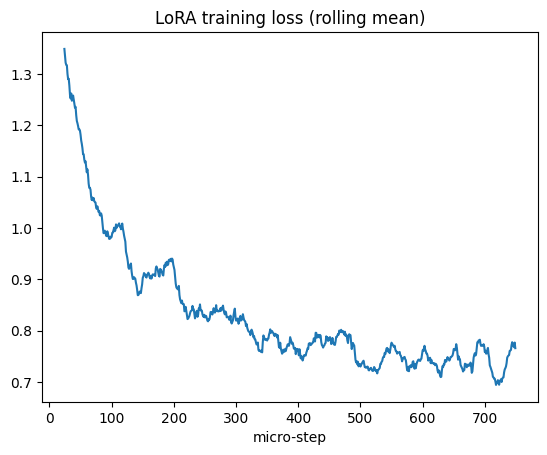

In [37]:
from peft import LoraConfig, get_peft_model
from transformers import get_cosine_schedule_with_warmup
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

llm_tok.padding_side = "right"
def encode_example(r):
    p_ids = llm_tok(mk_prompt(r.text, r.intent, r.category), add_special_tokens=False).input_ids
    r_ids = llm_tok(r.response + llm_tok.eos_token, add_special_tokens=False).input_ids
    ids = (p_ids + r_ids)[:MAX_SEQ]; labels = ([-100] * len(p_ids) + r_ids)[:MAX_SEQ]
    return ids, labels

sub = train_df.sample(N_LLM_TRAIN, random_state=SEED)
train_enc = [encode_example(r) for r in sub.itertuples()]
print("train examples:", len(train_enc), "| mean tokens:", int(np.mean([len(i) for i, _ in train_enc])))

def collate(batch):
    L = max(len(i) for i, _ in batch)
    ids = torch.full((len(batch), L), llm_tok.pad_token_id); lab = torch.full((len(batch), L), -100); att = torch.zeros((len(batch), L), dtype=torch.long)
    for k, (i, l) in enumerate(batch): ids[k, :len(i)] = torch.tensor(i); lab[k, :len(l)] = torch.tensor(l); att[k, :len(i)] = 1
    return dict(input_ids=ids, attention_mask=att, labels=lab)

MICRO_BS, GRAD_ACC = 4, 4
loader = DataLoader(train_enc, batch_size=MICRO_BS, shuffle=True, collate_fn=collate)

base.gradient_checkpointing_enable(); base.enable_input_require_grads(); base.config.use_cache = False
peft_model = get_peft_model(base, LoraConfig(r=16, lora_alpha=32, lora_dropout=0.05, task_type="CAUSAL_LM",
                                             target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]))
for p in peft_model.parameters():
    if p.requires_grad: p.data = p.data.float()
peft_model.print_trainable_parameters()

params = [p for p in peft_model.parameters() if p.requires_grad]
opt = torch.optim.AdamW(params, lr=2e-4, weight_decay=0.0)
total = (len(loader) // GRAD_ACC) * LLM_EPOCHS; sched = get_cosine_schedule_with_warmup(opt, int(0.05 * total), total)
scaler = torch.amp.GradScaler("cuda"); llm_losses = []; peft_model.train(); t0 = time.time()

for ep in range(LLM_EPOCHS):
    for step, batch in enumerate(tqdm(loader, desc=f"epoch {ep + 1}")):
        batch = {k: v.cuda() for k, v in batch.items()}
        with torch.autocast("cuda", dtype=torch.float16): loss = peft_model(**batch).loss / GRAD_ACC
        scaler.scale(loss).backward(); llm_losses.append(loss.item() * GRAD_ACC)
        if (step + 1) % GRAD_ACC == 0:
            scaler.unscale_(opt); torch.nn.utils.clip_grad_norm_(params, 1.0); scaler.step(opt); scaler.update(); opt.zero_grad(set_to_none=True); sched.step()
print(f"LoRA training: {(time.time() - t0) / 60:.1f} min | final loss (avg last 50): {np.mean(llm_losses[-50:]):.3f}")
plt.plot(pd.Series(llm_losses).rolling(25).mean()); plt.title("LoRA training loss (rolling mean)"); plt.xlabel("micro-step"); plt.show()

In [38]:
# merge adapter -> plain HF checkpoint (FP16) that vLLM can load
MERGED = str(ART / "qwen_ticket_merged")
peft_model.save_pretrained(str(ART / "qwen_lora_adapter"))
peft_model.eval(); merged = peft_model.merge_and_unload(); merged.gradient_checkpointing_disable(); merged.config.use_cache = True
merged = merged.half().eval(); merged.save_pretrained(MERGED, safe_serialization=True); llm_tok.save_pretrained(MERGED)
print("saved merged model:", MERGED, f"({sum(f.stat().st_size for f in Path(MERGED).glob('*.safetensors')) / 1e9:.2f} GB)")
del opt, scaler, peft_model, base; free_gpu()

llm_tok.padding_side = "left"
t0 = time.time(); ft_preds = hf_generate(merged, eval_prompts, bs=24); print(f"fine-tuned generation: {time.time() - t0:.0f}s")
GEN_RESULTS["Qwen2.5-1.5B + LoRA (HF fp16)"] = gen_metrics(ft_preds, eval_refs)
gen_df = pd.DataFrame(GEN_RESULTS).T.round(4); display(gen_df)
for k, v in GEN_RESULTS.items(): log_run("gen_" + k, {"system": k}, v)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

saved merged model: /content/work/artifacts/qwen_ticket_merged (3.09 GB)
fine-tuned generation: 38s


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,rouge1,rougeL,bertscore_f1,avg_words
BM25 retrieval,0.5519,0.3714,0.8613,111.4271
Qwen2.5-1.5B zero-shot,0.4221,0.2544,0.8100,85.5208
Qwen2.5-1.5B + LoRA (HF fp16),0.5338,0.3787,0.8587,82.1146


### 7.4 LLM-as-judge (optional) and manual review sheet
* **LLM-as-judge:** if an `ANTHROPIC_API_KEY` is available (Colab *Secrets* or env var), a strong model scores each reply 1–5 on helpfulness, relevance, tone and faithfulness (no invented specifics) against the reference. Without a key this cell is skipped.
* **Manual review:** a CSV with 50 samples is written for hand scoring (add columns `score_ft`, `score_retrieval`, notes).

In [42]:
KEY = None

try:
    from google.colab import userdata
    KEY = userdata.get("ANTHROPIC_API_KEY")
except Exception:
    KEY = os.environ.get("ANTHROPIC_API_KEY")


JUDGE_MODEL = "openai/gpt-oss-20b"

RUBRIC = (
    "You grade customer-support replies. Given the ticket, a reference reply "
    "and a candidate reply, score the CANDIDATE 1-5 on: "
    "helpfulness, relevance, tone, faithfulness "
    "(no invented order details/prices/dates; placeholders are fine). "
    'Respond with JSON only: '
    '{"helpfulness":int,"relevance":int,"tone":int,"faithfulness":int}'
)


def judge(client, ticket, ref, cand):

    msg = client.messages.create(
        model=JUDGE_MODEL,
        max_tokens=100,
        messages=[
            {
                "role": "user",
                "content": (
                    f"{RUBRIC}\n\n"
                    f"TICKET: {ticket}\n\n"
                    f"REFERENCE: {ref}\n\n"
                    f"CANDIDATE: {cand}"
                )
            }
        ]
    )

    text = msg.content[0].text

    match = re.search(r"\{.*\}", text, re.S)

    if not match:
        raise ValueError(f"No JSON found in judge response: {text[:300]}")

    return json.loads(match.group(0))


# ---------------------------------------------------------
# LLM-as-judge
# ---------------------------------------------------------

if KEY:

    import anthropic

    client = anthropic.Anthropic(api_key=KEY)

    N_J = min(40, len(ev))

    JUDGE = {}

    for name, preds in [
        ("BM25 retrieval", retr_preds),
        ("zero-shot", zs_preds),
        ("LoRA fine-tuned", ft_preds),
    ]:

        scores = []
        errors = 0

        for i in range(N_J):

            try:

                result = judge(
                    client,
                    ev.text.iloc[i] if hasattr(ev.text, "iloc") else ev.text[i],
                    eval_refs[i],
                    preds[i],
                )

                scores.append(result)

            except Exception as e:

                errors += 1

                if errors <= 3:
                    print(
                        f"{name} judge error at {i}: "
                        f"{type(e).__name__}: {e}"
                    )

        if scores:

            score_df = pd.DataFrame(scores)

            JUDGE[name] = score_df.mean(
                numeric_only=True
            ).round(2)

            print(
                f"{name}: {len(scores)}/{N_J} "
                f"judged successfully"
            )

        else:

            JUDGE[name] = None

            print(
                f"{name}: 0/{N_J} successful judge results"
            )


    # Safely construct the comparison table
    judge_rows = []

    for name, scores in JUDGE.items():

        if scores is None:
            continue

        row = {"model": name}

        if isinstance(scores, pd.Series):
            row.update(scores.to_dict())
        elif isinstance(scores, dict):
            row.update(scores)

        judge_rows.append(row)


    if judge_rows:

        judge_table = (
            pd.DataFrame(judge_rows)
            .set_index("model")
            .round(2)
        )

        display(judge_table)

    else:

        print(
            "No valid LLM-as-judge results were produced."
        )

else:

    print(
        "No ANTHROPIC_API_KEY found - skipping "
        "LLM-as-judge "
        "(ROUGE / BERTScore above remain valid)."
    )


# ---------------------------------------------------------
# Manual review CSV
# ---------------------------------------------------------

review = pd.DataFrame({
    "ticket": ev.text,
    "pred_intent": ev.pred_intent,
    "reference": eval_refs,
    "lora_reply": ft_preds,
    "retrieval_reply": retr_preds,
}).head(50)

review["score_lora_1to5"] = ""
review["score_retrieval_1to5"] = ""
review["notes"] = ""

review.to_csv(
    ART / "manual_review_50.csv",
    index=False
)

print(
    "wrote",
    ART / "manual_review_50.csv"
)

display(
    review[
        ["ticket", "lora_reply"]
    ].head(2)
)

No ANTHROPIC_API_KEY found - skipping LLM-as-judge (ROUGE / BERTScore above remain valid).
wrote /content/work/artifacts/manual_review_50.csv


,ticket,lora_reply
0,i want help towrite a comment for ur services,Thank you for expressing your interest in leav...
1,what do I have to do to check your rfund policy?,"I'll do my best! To check our refund policy, y..."


## 8. LLM serving optimization: HF `generate()` vs. vLLM
### 8.1 Baseline: Hugging Face `generate()` (static batching)
Greedy decoding, `max_new_tokens=200`, FP16, on the merged model. Batch latency is measured at batch sizes 1, 8, 32, and **throughput** is the full 96-prompt workload processed in batches of 32.

In [43]:
LLM_BENCH = {}   # name -> dict(latency{bs:{p50,p95,p99,tok_s}}, req_s, tok_s, size_gb, quality dict)

@torch.no_grad()
def bench_hf(model, prompts, bs_list=(1, 8, 32), n_batches={1: 8, 8: 4, 32: 3}):
    res = {}
    for bs in bs_list:
        lat, toks, torch_mem = [], 0, 0; torch.cuda.reset_peak_memory_stats()
        for b in range(n_batches[bs]):
            batch = prompts[(b * bs) % len(prompts):(b * bs) % len(prompts) + bs]
            enc = llm_tok(batch, return_tensors="pt", padding=True).to("cuda"); torch.cuda.synchronize(); t0 = time.perf_counter()
            gen = model.generate(**enc, max_new_tokens=MAX_NEW_TOKENS, do_sample=False, repetition_penalty=1.0, temperature=None, top_p=None, top_k=None, pad_token_id=llm_tok.pad_token_id)
            torch.cuda.synchronize(); dt = time.perf_counter() - t0; n = int((gen[:, enc.input_ids.shape[1]:] != llm_tok.pad_token_id).sum()); lat.append(dt * 1000); toks += n
        res[bs] = dict(**pctl(lat), tok_s=toks / (np.sum(lat) / 1000), peak_gb=torch.cuda.max_memory_allocated() / 1e9)
    # full workload throughput, batch 32
    n_tok, t0 = 0, time.perf_counter()
    for i in range(0, len(prompts), 32):
        enc = llm_tok(prompts[i:i + 32], return_tensors="pt", padding=True).to("cuda")
        gen = model.generate(**enc, max_new_tokens=MAX_NEW_TOKENS, do_sample=False, repetition_penalty=1.0, temperature=None, top_p=None, top_k=None, pad_token_id=llm_tok.pad_token_id)
        n_tok += int((gen[:, enc.input_ids.shape[1]:] != llm_tok.pad_token_id).sum())
    torch.cuda.synchronize(); T = time.perf_counter() - t0
    return dict(latency=res, req_s=len(prompts) / T, tok_s=n_tok / T)

_ = hf_generate(merged, eval_prompts[:4], bs=4, max_new_tokens=8)                # warm-up
hf_res = bench_hf(merged, eval_prompts)
hf_res["size_gb"] = sum(f.stat().st_size for f in Path(MERGED).glob("*.safetensors")) / 1e9
hf_res["quality"] = GEN_RESULTS["Qwen2.5-1.5B + LoRA (HF fp16)"]; LLM_BENCH["HF generate FP16"] = hf_res
print(json.dumps({k: v for k, v in hf_res.items() if k in ("req_s", "tok_s")}, indent=1)); display(pd.DataFrame(hf_res["latency"]).T.round(1))
del merged; free_gpu(); print("GPU used after cleanup (MB):", gpu_used_mb())

{
 "req_s": 3.062830514960107,
 "tok_s": 302.61403577496475
}


,p50,p95,p99,tok_s,peak_gb
1,2827.5,4412.6,4664.5,23.4,4.0
8,5676.5,8239.1,8443.8,120.2,4.1
32,10322.5,10716.0,10751.0,305.5,4.4


GPU used after cleanup (MB): 1353


### 8.2 vLLM environment (isolated virtualenv)
vLLM is installed into its own venv via `uv` so it cannot disturb the PyTorch/TensorRT/ONNX stack above. First install is large (several GB) and takes a few minutes.

**T4 notes:** the T4 (compute capability 7.5) has no BF16 and no FlashAttention-2, so we use `dtype=half`. The runner below automatically retries with alternative attention backends (`TRITON_ATTN`, then `XFORMERS`) if the default backend is not supported by your vLLM version.

In [44]:
%%bash
set -e
mkdir -p /content/venvs
if [ ! -x /content/venvs/vllm/bin/python ]; then
  uv venv /content/venvs/vllm
  uv pip install --python /content/venvs/vllm/bin/python vllm bitsandbytes
fi
/content/venvs/vllm/bin/python -c "import vllm; print('vLLM', vllm.__version__)"

vLLM 0.31.0


Using CPython 3.13.15 interpreter at: /usr/bin/python3
Creating virtual environment at: venvs/vllm
Activate with: source venvs/vllm/bin/activate
Using Python 3.13.15 environment at: venvs/vllm
Resolved 200 packages in 1.30s
Prepared 200 packages in 4m 17s
Installed 200 packages in 1.98s
 + agent-detector==2.0.0
 + aiohappyeyeballs==2.7.1
 + aiohttp==3.14.4
 + aiosignal==1.4.0
 + annotated-doc==0.0.5
 + annotated-types==0.8.0
 + anthropic==1.11.0
 + anyio==4.15.1
 + apache-tvm-ffi==0.1.11
 + astor==0.8.1
 + attrs==26.1.0
 + bitsandbytes==0.50.2
 + blake3==1.0.10
 + cachetools==7.2.1
 + cbor2==6.1.5
 + certifi==2026.7.22
 + cffi==2.1.1
 + charset-normalizer==3.5.2
 + click==8.5.0
 + cloudpickle==3.1.2
 + compressed-tensors==0.17.0
 + cryptography==50.0.2
 + cuda-bindings==13.4.3
 + cuda-core==1.2.1
 + cuda-pathfinder==1.8.3
 + cuda-python==13.4.1
 + cuda-tile==1.6.0
 + cuda-toolkit==13.0.3.0
 + depyf==0.20.0
 + detect-installer==0.2.1
 + dill==0.4.1
 + dnspython==2.8.0
 + docstring-parse

### 8.3 vLLM benchmark script
One process per variant (so GPU memory is fully released between runs). For each variant it measures batch latency at sizes 1/8/32 and a **saturated-throughput** run (all 96 prompts at once, where continuous batching + PagedAttention shine), then writes the generated texts for quality scoring.

With prefix caching enabled, the cache is reset at the start of each phase and primed with a *different* ticket carrying the same system prompt, so the speed-up reflects the **shared prefix only**, not repeated identical prompts.

In [45]:
%%writefile /content/work/artifacts/vllm_bench.py
import argparse, json, os, time
import numpy as np


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--model", required=True); ap.add_argument("--name", required=True); ap.add_argument("--prompts", required=True)
    ap.add_argument("--out", required=True); ap.add_argument("--quant", default=None); ap.add_argument("--prefix_caching", type=int, default=1)
    ap.add_argument("--max_tokens", type=int, default=200); ap.add_argument("--max_model_len", type=int, default=1024)
    ap.add_argument("--gpu_util", type=float, default=0.75); ap.add_argument("--enforce_eager", type=int, default=0)
    a = ap.parse_args()

    from vllm import LLM, SamplingParams
    data = json.load(open(a.prompts)); prompts, primer = data["prompts"], data["primer"]
    kw = dict(model=a.model, dtype="half", max_model_len=a.max_model_len, gpu_memory_utilization=a.gpu_util,
              enable_prefix_caching=bool(a.prefix_caching), seed=0)
    if a.quant: kw["quantization"] = a.quant
    if a.enforce_eager: kw["enforce_eager"] = True
    llm = LLM(**kw)
    sp = SamplingParams(temperature=0.0, max_tokens=a.max_tokens, repetition_penalty=1.0)
    primer_sp = SamplingParams(temperature=0.0, max_tokens=1)

    def phase_start():
        if a.prefix_caching:
            try: llm.reset_prefix_cache()
            except Exception: pass
            llm.generate([primer], primer_sp, use_tqdm=False)     # caches the shared system-prompt prefix only

    llm.generate(prompts[:8], sp, use_tqdm=False)                  # warm-up (compile / cuda graphs)
    res = {"name": a.name, "latency": {}}
    for bs, nb in [(1, 24), (8, 12), (32, 3)]:
        phase_start(); lat, toks = [], 0
        for b in range(nb):
            s = (b * bs) % len(prompts); batch = prompts[s:s + bs]
            t0 = time.perf_counter(); outs = llm.generate(batch, sp, use_tqdm=False); lat.append((time.perf_counter() - t0) * 1000)
            toks += sum(len(o.outputs[0].token_ids) for o in outs)
        res["latency"][str(bs)] = dict(p50=float(np.percentile(lat, 50)), p95=float(np.percentile(lat, 95)), p99=float(np.percentile(lat, 99)),
                                       tok_s=toks / (sum(lat) / 1000))
    phase_start(); t0 = time.perf_counter(); outs = llm.generate(prompts, sp, use_tqdm=False); T = time.perf_counter() - t0
    res["req_s"] = len(prompts) / T; res["tok_s"] = sum(len(o.outputs[0].token_ids) for o in outs) / T
    res["outputs"] = [o.outputs[0].text.strip() for o in outs]
    res["size_gb"] = sum(os.path.getsize(os.path.join(a.model, f)) for f in os.listdir(a.model) if f.endswith(".safetensors")) / 1e9
    json.dump(res, open(a.out, "w"))
    print("DONE", a.name, "req/s=%.2f tok/s=%.1f" % (res["req_s"], res["tok_s"]))


if __name__ == "__main__":
    main()

Writing /content/work/artifacts/vllm_bench.py


In [46]:
VENV_PY = "/content/venvs/vllm/bin/python"
primer_prompt = mk_prompt("Hello, I have a question about my recent purchase and would like some help.", "check_invoice", "INVOICE")
json.dump({"prompts": eval_prompts, "primer": primer_prompt}, open(ART / "bench_prompts.json", "w"))
WORKING_BACKEND = None

def run_vllm_variant(name, model_dir, quant=None, prefix=True, enforce_eager=False):
    global WORKING_BACKEND
    out = ART / f"vllm_{name}.json"
    for backend in [None, "TRITON_ATTN", "XFORMERS"]:
        out.unlink(missing_ok=True); env = os.environ.copy()
        if backend: env["VLLM_ATTENTION_BACKEND"] = backend
        cmd = [VENV_PY, str(ART / "vllm_bench.py"), "--model", model_dir, "--name", name, "--prompts", str(ART / "bench_prompts.json"),
               "--out", str(out), "--prefix_caching", str(int(prefix)), "--enforce_eager", str(int(enforce_eager)), "--max_tokens", str(MAX_NEW_TOKENS)]
        if quant: cmd += ["--quant", quant]
        t0 = time.time(); r = subprocess.run(cmd, env=env, capture_output=True, text=True)
        if out.exists():
            WORKING_BACKEND = backend if backend else WORKING_BACKEND; print(f"[{name}] ok in {time.time() - t0:.0f}s (attention backend: {backend or 'default'})")
            return json.loads(out.read_text())
        print(f"[{name}] failed with backend={backend}. Last log lines:\n", (r.stdout + r.stderr)[-1200:])
    return None

VLLM_RAW = {}
if RUN_VLLM:
    free_gpu()
    VLLM_RAW["vLLM FP16 (prefix cache ON)"] = run_vllm_variant("fp16_prefix_on", MERGED, prefix=True)
    VLLM_RAW["vLLM FP16 (prefix cache OFF)"] = run_vllm_variant("fp16_prefix_off", MERGED, prefix=False)

[fp16_prefix_on] ok in 243s (attention backend: default)
[fp16_prefix_off] ok in 164s (attention backend: default)


### 8.4 Quantized weights: AWQ (4-bit) and in-flight 4-bit (bitsandbytes)
* **AWQ** – activation-aware 4-bit weight quantization, calibrated on 128 fine-tuned-format training prompts, using **AutoAWQ in its own venv** (AutoAWQ pins older `transformers`/`torch`). The AutoAWQ checkpoint format is loaded by vLLM's `awq` kernels, which work on the T4 (the newer Marlin-based formats require Ampere or newer).
* **bitsandbytes NF4** – vLLM quantizes the FP16 checkpoint on load; no calibration, used as a fallback/second data point.

If AutoAWQ fails to install or quantize in your Colab image, the notebook continues and reports the other variants.

In [47]:
%%writefile /content/work/artifacts/awq_quant.py
import json, sys, torch
from awq import AutoAWQForCausalLM
from transformers import AutoTokenizer

src, dst, calib = sys.argv[1], sys.argv[2], sys.argv[3]
texts = json.load(open(calib))
tok = AutoTokenizer.from_pretrained(src)
model = AutoAWQForCausalLM.from_pretrained(src, low_cpu_mem_usage=True, use_cache=False)
model.quantize(tok, quant_config={"zero_point": True, "q_group_size": 128, "w_bit": 4, "version": "GEMM"},
               calib_data=texts, max_calib_samples=len(texts), max_calib_seq_len=512)
model.save_quantized(dst); tok.save_pretrained(dst)
print("AWQ saved to", dst)

Writing /content/work/artifacts/awq_quant.py


In [48]:
AWQ_DIR = str(ART / "qwen_ticket_awq")
if RUN_VLLM and RUN_AWQ:
    try:
        subprocess.run("""set -e
        if [ ! -x /content/venvs/awq/bin/python ]; then
          uv venv /content/venvs/awq
          uv pip install --python /content/venvs/awq/bin/python autoawq "transformers<4.52"
        fi""", shell=True, check=True, executable="/bin/bash")
        calib_texts = [llm_tok.apply_chat_template(build_messages(r.text, r.intent, r.category) + [{"role": "assistant", "content": r.response}], tokenize=False)
                       for r in train_df.sample(128, random_state=1).itertuples()]
        json.dump(calib_texts, open(ART / "awq_calib.json", "w"))
        t0 = time.time(); r = subprocess.run(["/content/venvs/awq/bin/python", str(ART / "awq_quant.py"), MERGED, AWQ_DIR, str(ART / "awq_calib.json")], capture_output=True, text=True)
        print(f"AWQ quantization took {(time.time() - t0) / 60:.1f} min"); print((r.stdout + r.stderr)[-800:])
    except Exception as e:
        print("AWQ environment/quantization failed:", repr(e)[:300])

if RUN_VLLM:
    if Path(AWQ_DIR, "config.json").exists(): VLLM_RAW["vLLM AWQ-4bit (prefix cache ON)"] = run_vllm_variant("awq_prefix_on", AWQ_DIR, prefix=True)
    else: print("AWQ checkpoint not available - skipping AWQ variant")
    VLLM_RAW["vLLM bnb-NF4 (prefix cache ON)"] = run_vllm_variant("bnb_prefix_on", MERGED, quant="bitsandbytes", prefix=True)

AWQ quantization took 0.4 min
       ^^^^^^^^^
    )
    ^
  File "/content/venvs/awq/lib/python3.13/site-packages/transformers/tokenization_utils_base.py", line 2303, in _from_pretrained
    except import_protobuf_decode_error():
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/content/venvs/awq/lib/python3.13/site-packages/transformers/tokenization_utils_base.py", line 87, in import_protobuf_decode_error
    raise ImportError(PROTOBUF_IMPORT_ERROR.format(error_message))
ImportError: 
 requires the protobuf library but it was not found in your environment. Checkout the instructions on the
installation page of its repo: https://github.com/protocolbuffers/protobuf/tree/master/python#installation and follow the ones
that match your environment. Please note that you may need to restart your runtime after installation.


AWQ checkpoint not available - skipping AWQ variant
[bnb_prefix_on] failed with backend=None. Last log lines:
 onfig
    return ModelConfig(
        model=self.model,
  

### 8.5 LLM benchmark table
Quality (ROUGE-L / BERTScore) is computed on the same 96 greedy outputs; the quantization quality delta is measured against the vLLM FP16 outputs. `size_gb` is the on-disk weight size; vLLM pre-allocates most of the remaining GPU memory for the KV-cache (PagedAttention), so `nvidia-smi` memory is not a meaningful comparison for vLLM.

In [49]:
for name, res in VLLM_RAW.items():
    if res is None: continue
    res["quality"] = gen_metrics(res["outputs"], eval_refs); LLM_BENCH[name] = res

rows = []
for name, r in LLM_BENCH.items():
    row = {"variant": name, "req_s": r["req_s"], "tok_s": r["tok_s"], "size_gb": r["size_gb"], "rougeL": r["quality"]["rougeL"], "bertscore_f1": r["quality"]["bertscore_f1"]}
    for bs in (1, 8, 32):
        L = r["latency"][bs] if bs in r["latency"] else r["latency"][str(bs)]
        row.update({f"p50@{bs}": L["p50"], f"p95@{bs}": L["p95"], f"p99@{bs}": L["p99"]})
    rows.append(row)
LLM_SUMMARY = pd.DataFrame(rows)
ref_row = LLM_SUMMARY[LLM_SUMMARY.variant.str.startswith("vLLM FP16 (prefix cache ON)")]
if len(ref_row): LLM_SUMMARY["d_rougeL_vs_vllm_fp16"] = LLM_SUMMARY.rougeL - float(ref_row.rougeL.iloc[0])
LLM_SUMMARY["speedup_vs_HF_tok_s"] = LLM_SUMMARY.tok_s / float(LLM_SUMMARY[LLM_SUMMARY.variant == "HF generate FP16"].tok_s.iloc[0])
display(LLM_SUMMARY.round(3)); LLM_SUMMARY.to_csv(ART / "llm_benchmark.csv", index=False)
for _, r in LLM_SUMMARY.iterrows(): log_run("llm_bench_" + r.variant, {"variant": r.variant}, {k: r[k] for k in ("req_s", "tok_s", "p50@1", "p50@32", "size_gb", "rougeL", "bertscore_f1")})

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,variant,req_s,tok_s,size_gb,rougeL,bertscore_f1,p50@1,p95@1,p99@1,p50@8,p95@8,p99@8,p50@32,p95@32,p99@32,d_rougeL_vs_vllm_fp16,speedup_vs_HF_tok_s
0,HF generate FP16,3.063,302.614,3.087,0.379,0.859,2827.516,4412.596,4664.521,5676.484,8239.126,8443.785,10322.524,10716.014,10750.991,-0.001,1.000
1,vLLM FP16 (prefix cache ON),14.979,1483.032,3.087,0.380,0.859,1354.793,1981.125,2822.011,2970.863,3424.599,3444.998,4313.708,4464.346,4477.736,0.000,4.901
2,vLLM FP16 (prefix cache OFF),11.440,1132.939,3.087,0.380,0.859,1516.204,2180.038,2847.495,3047.337,3541.927,3543.234,4930.025,5113.665,5129.988,0.000,3.744


## 9. Pareto plots: speed vs. quality
Left: **classifier** latency (batch 32, p50) against macro-F1 on the noisy test set (the more sensitive accuracy signal), with GPU and CPU variants distinguished by marker. Right: **LLM** generation throughput (tokens/s) against ROUGE-L. Points toward the **upper-left** (classifier) / **upper-right** (LLM) dominate. Dashed lines connect the Pareto-optimal points.

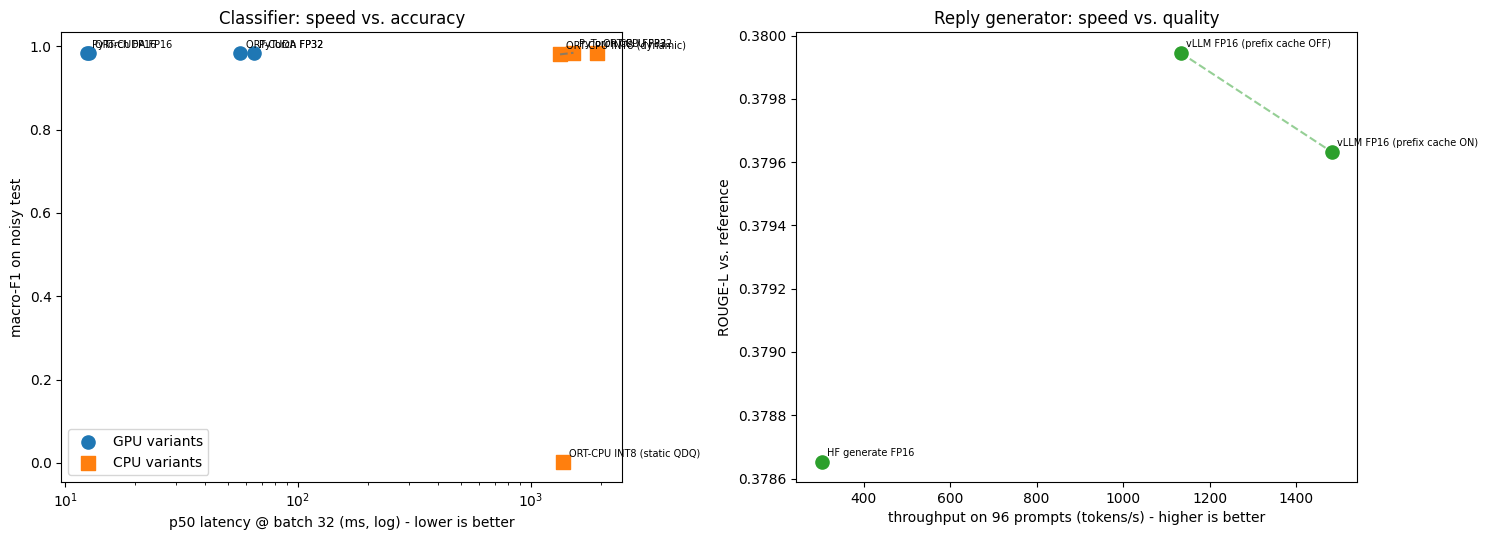

In [50]:
def pareto_front(xs, ys, higher_x_better):
    pts = sorted(zip(xs, ys), key=lambda p: p[0], reverse=higher_x_better); front, best = [], -np.inf
    for x, y in pts:
        if y > best: front.append((x, y)); best = y
    return sorted(front)

fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
for g, mk_ in (("GPU", "o"), ("CPU", "s")):
    d = CLS_SUMMARY[CLS_SUMMARY.group == g]
    ax[0].scatter(d["p50@32"], d.f1_noisy, s=90, marker=mk_, label=f"{g} variants")
    for _, r in d.iterrows(): ax[0].annotate(r.variant, (r["p50@32"], r.f1_noisy), fontsize=7, xytext=(4, 4), textcoords="offset points")
    f = pareto_front(d["p50@32"].values, d.f1_noisy.values, higher_x_better=False)
    if len(f) > 1: ax[0].plot(*zip(*f), "--", alpha=0.5)
ax[0].set(xscale="log", xlabel="p50 latency @ batch 32 (ms, log) - lower is better", ylabel="macro-F1 on noisy test", title="Classifier: speed vs. accuracy"); ax[0].legend()

d = LLM_SUMMARY
ax[1].scatter(d.tok_s, d.rougeL, s=90, c="tab:green")
for _, r in d.iterrows(): ax[1].annotate(r.variant, (r.tok_s, r.rougeL), fontsize=7, xytext=(4, 4), textcoords="offset points")
f = pareto_front(d.tok_s.values, d.rougeL.values, higher_x_better=True)
if len(f) > 1: ax[1].plot(*zip(*f), "--", c="tab:green", alpha=0.5)
ax[1].set(xlabel="throughput on 96 prompts (tokens/s) - higher is better", ylabel="ROUGE-L vs. reference", title="Reply generator: speed vs. quality")
plt.tight_layout(); plt.savefig(ART / "pareto.png", dpi=160); plt.show()

## 10. Deployment
### 10.1 FastAPI service (+ vLLM OpenAI-compatible server)
Architecture: `POST /ticket` → **ONNX Runtime (GPU, FP16)** classifier → prompt built with the *shared* `ticket_utils.build_messages` → **vLLM server** (continuous batching, prefix caching) → reply. `/classify` exposes the classifier alone. The same code can be containerized (Dockerfile below) or moved behind **Triton Inference Server** (ONNX/TensorRT backends for the classifier, vLLM backend for the LLM).

In [51]:
%%writefile /content/work/serve/app.py
import json, os, sys, time
import numpy as np, httpx, onnxruntime as ort
from fastapi import FastAPI
from pydantic import BaseModel
from transformers import AutoTokenizer

ART = os.environ.get("ART_DIR", "/content/work/artifacts")
sys.path.insert(0, os.environ.get("UTILS_DIR", "/content/work"))
from ticket_utils import clean_text, build_messages

cfg = json.load(open(f"{ART}/config.json"))
tok = AutoTokenizer.from_pretrained(f"{ART}/distilbert_ticket")
sess = ort.InferenceSession(os.environ.get("CLS_ONNX", f"{ART}/onnx/model_fp16.onnx"),
                            providers=["CUDAExecutionProvider", "CPUExecutionProvider"])
VLLM_URL = os.environ.get("VLLM_URL", "http://127.0.0.1:8001/v1/chat/completions")
LLM_NAME = os.environ.get("LLM_NAME", "ticket-llm")
URGENT = set(cfg["urgent_intents"]); INTENTS = cfg["intents"]; I2C = cfg["intent2cat"]
URGENT_IDX = [i for i, n in enumerate(INTENTS) if n in URGENT]

app = FastAPI(title="Support Ticket Intelligence")
client = httpx.AsyncClient(timeout=120)


class Ticket(BaseModel):
    text: str
    draft_reply: bool = True
    max_tokens: int = 200


def classify(text: str):
    enc = tok([clean_text(text)], padding="max_length", truncation=True, max_length=cfg["max_len"], return_tensors="np")
    logits = sess.run(None, {"input_ids": enc["input_ids"].astype(np.int64), "attention_mask": enc["attention_mask"].astype(np.int64)})[0][0]
    p = np.exp(logits - logits.max()); p /= p.sum(); i = int(p.argmax())
    return {"intent": INTENTS[i], "category": I2C[INTENTS[i]], "confidence": float(p[i]), "urgent_score": float(p[URGENT_IDX].sum()),
            "priority": "urgent" if p[URGENT_IDX].sum() > 0.5 else "normal"}


@app.get("/health")
def health():
    return {"status": "ok", "providers": sess.get_providers()}


@app.post("/classify")
def classify_ep(t: Ticket):
    t0 = time.perf_counter(); out = classify(t.text); out["latency_ms"] = (time.perf_counter() - t0) * 1000; return out


@app.post("/ticket")
async def ticket_ep(t: Ticket):
    t0 = time.perf_counter(); out = classify(t.text); out["classify_ms"] = (time.perf_counter() - t0) * 1000
    if t.draft_reply:
        msgs = build_messages(clean_text(t.text), out["intent"], out["category"]); t1 = time.perf_counter()
        r = await client.post(VLLM_URL, json={"model": LLM_NAME, "messages": msgs, "temperature": 0.0, "max_tokens": t.max_tokens})
        r.raise_for_status(); out["reply"] = r.json()["choices"][0]["message"]["content"].strip(); out["llm_ms"] = (time.perf_counter() - t1) * 1000
    out["total_ms"] = (time.perf_counter() - t0) * 1000
    return out

Writing /content/work/serve/app.py


In [52]:
%%writefile /content/work/serve/locustfile.py
import json, random
from locust import HttpUser, task, between

TICKETS = json.load(open("/content/work/serve/sample_tickets.json"))


class SupportUser(HttpUser):
    wait_time = between(0.1, 0.5)

    @task(1)
    def classify_only(self):
        self.client.post("/classify", json={"text": random.choice(TICKETS)}, name="/classify")

    @task(3)
    def full_pipeline(self):
        self.client.post("/ticket", json={"text": random.choice(TICKETS), "max_tokens": 128}, name="/ticket")

Writing /content/work/serve/locustfile.py


In [53]:
%%writefile /content/work/serve/Dockerfile
# Build:  docker build -t ticket-intel -f Dockerfile .   (context must contain app.py, ticket_utils.py, artifacts/)
# Run:    docker run --gpus all -p 8000:8000 -e VLLM_URL=http://vllm:8001/v1/chat/completions ticket-intel
# The vLLM server runs as a separate container, e.g.:
#   docker run --gpus all -p 8001:8001 -v $PWD/artifacts/qwen_ticket_merged:/model vllm/vllm-openai:latest \
#     --model /model --served-model-name ticket-llm --dtype half --max-model-len 1024 --enable-prefix-caching --port 8001
FROM nvidia/cuda:12.4.1-cudnn-runtime-ubuntu22.04
RUN apt-get update && apt-get install -y python3 python3-pip && rm -rf /var/lib/apt/lists/*
WORKDIR /app
COPY requirements.txt .
RUN pip3 install --no-cache-dir -r requirements.txt
COPY app.py ticket_utils.py ./
COPY artifacts ./artifacts
ENV ART_DIR=/app/artifacts UTILS_DIR=/app
EXPOSE 8000
CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]

Writing /content/work/serve/Dockerfile


In [54]:
%%writefile /content/work/serve/requirements.txt
fastapi
uvicorn[standard]
httpx
onnxruntime-gpu
transformers
numpy
pydantic

Writing /content/work/serve/requirements.txt


### 10.2 Run it: vLLM server → FastAPI → smoke test → Locust load test
Starts the vLLM OpenAI-compatible server (60% of GPU memory, prefix caching on) and the FastAPI app (ONNX Runtime FP16 classifier) as background processes, sends a few tickets, then runs a 40-second headless Locust test with 8 simulated users.

In [55]:
import requests, signal
SERVERS = []
def wait_http(url, timeout=420):
    t0 = time.time()
    while time.time() - t0 < timeout:
        try:
            if requests.get(url, timeout=3).status_code == 200: return True
        except Exception: pass
        time.sleep(5)
    return False

if RUN_DEPLOY_DEMO and RUN_VLLM:
    free_gpu()
    json.dump(test_df.text.sample(200, random_state=7).tolist(), open(SERVE / "sample_tickets.json", "w"))
    env = os.environ.copy()
    if WORKING_BACKEND: env["VLLM_ATTENTION_BACKEND"] = WORKING_BACKEND
    vllm_srv = subprocess.Popen([VENV_PY, "-m", "vllm.entrypoints.openai.api_server", "--model", MERGED, "--served-model-name", "ticket-llm", "--dtype", "half",
                                 "--max-model-len", "1024", "--gpu-memory-utilization", "0.6", "--enable-prefix-caching", "--port", "8001"],
                                stdout=open(WORK / "vllm_server.log", "w"), stderr=subprocess.STDOUT, env=env); SERVERS.append(vllm_srv)
    print("vLLM server up:", wait_http("http://127.0.0.1:8001/health"))

    app_env = dict(os.environ, ART_DIR=str(ART), UTILS_DIR=str(WORK), CLS_ONNX=onnx_fp16 if Path(onnx_fp16).exists() else onnx_fp32)
    api = subprocess.Popen([sys.executable, "-m", "uvicorn", "app:app", "--app-dir", str(SERVE), "--port", "8000"],
                           stdout=open(WORK / "api.log", "w"), stderr=subprocess.STDOUT, env=app_env); SERVERS.append(api)
    print("FastAPI up:", wait_http("http://127.0.0.1:8000/health"))

vLLM server up: True
FastAPI up: True


In [56]:
if RUN_DEPLOY_DEMO and RUN_VLLM:
    for q in ["hi i cant remember my pasword and i am locked out of my account!!", "I want to know where my order is, it was supposed to arrive last week",
              "why was i charged twice for the same order? this is unacceptable"]:
        r = requests.post("http://127.0.0.1:8000/ticket", json={"text": q, "max_tokens": 150}, timeout=120).json()
        print("TICKET:", q); print({k: (round(v, 3) if isinstance(v, float) else v) for k, v in r.items() if k != "reply"}); print("REPLY :", r.get("reply", "")[:400], "\n")

TICKET: hi i cant remember my pasword and i am locked out of my account!!
{'intent': 'delete_account', 'category': 'ACCOUNT', 'confidence': 0.993, 'urgent_score': 0.005, 'priority': 'normal', 'classify_ms': 623.472, 'llm_ms': 5970.264, 'total_ms': 6593.847}
REPLY : I'm sorry to hear that you're having trouble remembering your password and being locked out of your account. Don't worry, I'm here to assist you with resolving this issue. To regain access to your account, please follow these steps:

1. Visit our website at {{Website URL}}.
2. Look for the "Forgot Password" option on the login page.
3. Click on it and enter the email associated with your account.
 

TICKET: I want to know where my order is, it was supposed to arrive last week
{'intent': 'delivery_period', 'category': 'DELIVERY', 'confidence': 0.996, 'urgent_score': 0.001, 'priority': 'normal', 'classify_ms': 29.116, 'llm_ms': 1673.005, 'total_ms': 1702.218}
REPLY : I'm on the same wavelength that you're eager to track the wh

In [57]:
if RUN_DEPLOY_DEMO and RUN_VLLM:
    os.makedirs(WORK / "locust", exist_ok=True)
    r = subprocess.run([sys.executable, "-m", "locust", "-f", str(SERVE / "locustfile.py"), "--headless", "-u", "8", "-r", "2", "-t", "40s",
                        "--host", "http://127.0.0.1:8000", "--csv", str(WORK / "locust" / "run")], capture_output=True, text=True)
    stats = pd.read_csv(WORK / "locust" / "run_stats.csv")
    display(stats[["Name", "Request Count", "Failure Count", "Median Response Time", "Average Response Time", "95%", "99%", "Requests/s"]].round(1))

,Name,Request Count,Failure Count,Median Response Time,Average Response Time,95%,99%,Requests/s
0,/classify,51,0,8,12.1,50,86,1.3
1,/ticket,125,0,1900,1901.3,2400,2400,3.2
2,Aggregated,176,0,1600,1353.8,2400,2400,4.5


In [58]:
# shut the background servers down and free the GPU
for p in SERVERS:
    try: p.terminate(); p.wait(timeout=30)
    except Exception: p.kill()
SERVERS.clear(); time.sleep(3); print("GPU used (MB):", gpu_used_mb())

GPU used (MB): 1353


## 11. Summary
### 11.1 Final tables

In [59]:
print("=== Classifier: quality ===")
display(eval_df.pivot(index="model", columns="split", values=["macro_f1", "ece"]).round(4))
print("=== Classifier: optimization ===")
display(CLS_SUMMARY[["group", "variant", "p50@1", "p50@32", "p99@32", "rps@32", "gpu_mem_mb", "f1_noisy", "d_f1_noisy"]].round(3).sort_values(["group", "p50@32"]))
print("=== Reply generator: quality ===")
display(gen_df)
print("=== Reply generator: serving ===")
display(LLM_SUMMARY[["variant", "tok_s", "req_s", "p50@1", "p50@32", "size_gb", "rougeL", "speedup_vs_HF_tok_s"]].round(3))

if SAVE_TO_DRIVE:
    from google.colab import drive; drive.mount("/content/drive")
    subprocess.run(f"mkdir -p /content/drive/MyDrive/ticket_intel && cp -r {ART} /content/drive/MyDrive/ticket_intel/ && cp -r {SERVE} /content/drive/MyDrive/ticket_intel/", shell=True)
    print("artifacts copied to Google Drive")

=== Classifier: quality ===


macro_f1             ece        
split             clean   noisy   clean   noisy
model                                          
DistilBERT       0.9980  0.9836  0.0006  0.0095
TFIDF+LR         0.9944  0.9659  0.0218  0.0394
TFIDF+LightGBM   0.9878  0.9558  0.0088  0.0160

=== Classifier: optimization ===


,group,variant,p50@1,p50@32,p99@32,rps@32,gpu_mem_mb,f1_noisy,d_f1_noisy
1,CPU,ORT-CPU INT8 (dynamic),40.380,1338.066,1788.019,22.555,0,0.981,-0.004
2,CPU,ORT-CPU INT8 (static QDQ),63.796,1381.003,1884.851,21.589,0,0.003,-0.982
3,CPU,PyTorch CPU FP32,93.616,1528.586,2128.304,19.810,0,0.984,0.000
0,CPU,ORT-CPU FP32,61.384,1928.707,2766.965,15.556,0,0.984,0.000
6,GPU,PyTorch FP16,7.382,12.383,12.929,2582.679,70,0.984,0.000
4,GPU,ORT-CUDA FP16,2.194,12.651,12.925,2524.006,270,0.984,0.000
5,GPU,ORT-CUDA FP32,3.257,56.633,57.655,563.967,538,0.984,0.000
7,GPU,PyTorch FP32,5.143,64.641,66.301,495.886,280,0.984,0.000


=== Reply generator: quality ===


,rouge1,rougeL,bertscore_f1,avg_words
BM25 retrieval,0.5519,0.3714,0.8613,111.4271
Qwen2.5-1.5B zero-shot,0.4221,0.2544,0.8100,85.5208
Qwen2.5-1.5B + LoRA (HF fp16),0.5338,0.3787,0.8587,82.1146


=== Reply generator: serving ===


,variant,tok_s,req_s,p50@1,p50@32,size_gb,rougeL,speedup_vs_HF_tok_s
0,HF generate FP16,302.614,3.063,2827.516,10322.524,3.087,0.379,1.000
1,vLLM FP16 (prefix cache ON),1483.032,14.979,1354.793,4313.708,3.087,0.380,4.901
2,vLLM FP16 (prefix cache OFF),1132.939,11.440,1516.204,4930.025,3.087,0.380,3.744


### 11.2 What this project demonstrates and how to extend it

**Workflow coverage:** data collection and versioning → cleaning/PII/dedupe → engineered features → class-imbalance handling → classical baselines with CV → transformer fine-tuning → calibration, PR curves, bootstrap CIs, slice analysis, drift (PSI/KS) → ONNX/ORT/TensorRT optimization → LoRA fine-tuned generator vs. retrieval/zero-shot baselines → vLLM serving experiments → FastAPI + Locust + Docker + MLflow.

**Things to try next**

* Replace Bitext with real tickets (or add Banking77 / StackExchange data) so that urgency and timestamps are real, then restore the **time-based split** and a true urgency label.
* Use `trtexec --best` or TensorRT-LLM to compare against the Python builder path; try FP8/INT8 SmoothQuant on an Ampere/Ada GPU.
* Add speculative decoding or a larger Qwen2.5-3B under AWQ in vLLM; add LoRA-adapter serving (`--enable-lora`) to hot-swap per-tenant styles.
* Wrap the classifier in **Triton** with dynamic batching and compare p99 latency under Locust with the FastAPI version.
* Generate an Evidently drift report from live traffic, and view all runs with `mlflow ui --backend-store-uri file:/content/work/mlruns`.